**EcoTroph-RAG: A Retrieval-Augmented Ecological Intelligence Framework for Freshwater Fish Diet Analysis**

**Summary:**

We used a lightweight retrieval-augmented generation (RAG) system over the TroPhish freshwater fish diet dataset.
Each tabular row was first converted into an ecological text unit describing fish species, prey taxon, prey class, prey origin, prey stage, habitat, diet percentage, and geographic location. These ecological text units were embedded using Hugging Face sentence-embedding models and indexed in Chroma for semantic retrieval.

For a user query, the system retrieved the most relevant TroPhish records using vector similarity search. The retrieved evidence was then passed to summarization models such as BART-large-CNN and T5-base to generate concise ecological answers. Thus, the RAG pipeline combined dataset-grounded retrieval with abstractive summarization, ensuring that answers were based on actual TroPhish diet records rather than unsupported model generation.


**Prepared by:**

Partha Pratim Ray, Sikkim University, India, parthapratimray1986@gmail.com, ppray@cus.ac.in, May, 2026

In [2]:
# Cell 1: Install libraries

!pip install -q pandas numpy chromadb sentence-transformers transformers torch scikit-learn tqdm rank-bm25 rouge-score psutil matplotlib seaborn FlagEmbedding

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 247.7/247.7 kB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 866.1/866.1 kB 29.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 149.7/149.7 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.6/45.6 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 60.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 50.1 MB/s eta 0:00:00


In [4]:
# Cell 2: Import libraries

import os
import re
import time
import json
import psutil
import numpy as np
import pandas as pd
from tqdm import tqdm

import chromadb
from sentence_transformers import SentenceTransformer
from transformers import pipeline

from rank_bm25 import BM25Okapi
from sklearn.metrics import ndcg_score
from rouge_score import rouge_scorer

import matplotlib.pyplot as plt
import seaborn as sns

import torch
from FlagEmbedding import BGEM3FlagModel
from sentence_transformers import SentenceTransformer

In [5]:
# Cell 3: Upload TroPhish CSV

from google.colab import files

uploaded = files.upload()

csv_path = list(uploaded.keys())[0]
print("Uploaded file:", csv_path)

Saving trophish_dataset.csv to trophish_dataset.csv
Uploaded file: trophish_dataset.csv


In [6]:
# Cell 4: Load dataset

df = pd.read_csv(csv_path)

print("Shape:", df.shape)
print(df.head())
print(df.columns.tolist())

Shape: (54750, 26)
           fish_species prey_kingdom         prey_taxon prey_class  \
0   Notropis biguttatus      Metazoa  crustacea remains        NaN   
1   Notropis micropogon      Metazoa  crustacea remains        NaN   
2   Notropis biguttatus      Metazoa  crustacea remains        NaN   
3   Notropis micropogon      Metazoa  crustacea remains        NaN   
4  Salvelinus namaycush      Metazoa             aranea  Arachnida   

  prey_origin prey_stage  diet_value diet_units  diet_type  diet_percent  ...  \
0         NaN        NaN        0.30    percent     volume          0.30  ...   
1         NaN        NaN        0.00    percent     volume          0.00  ...   
2         NaN        NaN        0.00    percent     volume          0.00  ...   
3         NaN        NaN        0.00    percent     volume          0.00  ...   
4         NaN        NaN        0.01    percent  abundance          0.01  ...   

             data_sorted_by  fish_min_length fish_average_length  \
0    

In [7]:
#Cell 5: Basic cleaning

df = df.copy()

df.columns = [c.strip().lower() for c in df.columns]

df = df.replace(["NA", "NaN", "nan", "", " "], np.nan)

for col in df.columns:
    if df[col].dtype == "object":
        df[col] = df[col].astype(str).str.strip()
        df[col] = df[col].replace(["nan", "None"], np.nan)

numeric_cols = [
    "diet_value", "diet_percent", "longitude", "latitude",
    "fish_min_length", "fish_average_length", "fish_max_length"
]

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

print("Cleaned shape:", df.shape)
df.head()

Cleaned shape: (54750, 26)


,fish_species,prey_kingdom,prey_taxon,prey_class,prey_origin,prey_stage,diet_value,diet_units,diet_type,diet_percent,...,data_sorted_by,fish_min_length,fish_average_length,fish_max_length,fish_length_units,fish_length_measure,habitat_broad,habitat,longitude,latitude
0,Notropis biguttatus,Metazoa,crustacea remains,NaN,NaN,NaN,0.30,percent,volume,0.30,...,NaN,3.31,NaN,3.31,cm,NaN,lotic,lotic,-78.005010,43.298690
1,Notropis micropogon,Metazoa,crustacea remains,NaN,NaN,NaN,0.00,percent,volume,0.00,...,NaN,3.45,NaN,3.45,cm,NaN,lotic,lotic,-78.005010,43.298690
2,Notropis biguttatus,Metazoa,crustacea remains,NaN,NaN,NaN,0.00,percent,volume,0.00,...,NaN,5.56,NaN,5.56,cm,NaN,lotic,lotic,-78.005010,43.298690
3,Notropis micropogon,Metazoa,crustacea remains,NaN,NaN,NaN,0.00,percent,volume,0.00,...,NaN,6.00,NaN,6.00,cm,NaN,lotic,lotic,-78.005010,43.298690
4,Salvelinus namaycush,Metazoa,aranea,Arachnida,NaN,NaN,0.01,percent,abundance,0.01,...,shallow water morphotype,NaN,NaN,NaN,NaN,NaN,lentic,lake,-120.819338,65.917958


In [8]:
# Cell 6: Dataset statistics for paper

stats = {
    "Total records": len(df),
    "Total columns": df.shape[1],
    "Unique fish species": df["fish_species"].nunique() if "fish_species" in df.columns else np.nan,
    "Unique prey taxa": df["prey_taxon"].nunique() if "prey_taxon" in df.columns else np.nan,
    "Unique prey classes": df["prey_class"].nunique() if "prey_class" in df.columns else np.nan,
    "Unique habitats": df["habitat"].nunique() if "habitat" in df.columns else np.nan,
    "Records with diet percent": df["diet_percent"].notna().sum() if "diet_percent" in df.columns else np.nan,
    "Records with latitude": df["latitude"].notna().sum() if "latitude" in df.columns else np.nan,
    "Records with longitude": df["longitude"].notna().sum() if "longitude" in df.columns else np.nan,
}

stats_df = pd.DataFrame(stats.items(), columns=["Measure", "Value"])
stats_df


,Measure,Value
0,Total records,54750
1,Total columns,26
2,Unique fish species,981
3,Unique prey taxa,4211
4,Unique prey classes,84
5,Unique habitats,18
6,Records with diet percent,53216
7,Records with latitude,50450
8,Records with longitude,50450


In [9]:
# Cell 7: Convert rows into ecological text

def safe_value(row, col, default="not reported"):
    if col in row.index and pd.notna(row[col]):
        return str(row[col])
    return default

def row_to_ecological_text(row):
    fish = safe_value(row, "fish_species")
    prey_taxon = safe_value(row, "prey_taxon")
    prey_kingdom = safe_value(row, "prey_kingdom")
    prey_class = safe_value(row, "prey_class")
    prey_origin = safe_value(row, "prey_origin")
    prey_stage = safe_value(row, "prey_stage")
    diet_value = safe_value(row, "diet_value")
    diet_units = safe_value(row, "diet_units")
    diet_type = safe_value(row, "diet_type")
    diet_percent = safe_value(row, "diet_percent")
    habitat = safe_value(row, "habitat")
    longitude = safe_value(row, "longitude")
    latitude = safe_value(row, "latitude")

    text = (
        f"Fish species {fish} consumed prey taxon {prey_taxon} "
        f"from prey kingdom {prey_kingdom} and prey class {prey_class}. "
        f"The prey origin was {prey_origin} and prey stage was {prey_stage}. "
        f"The diet value was {diet_value} {diet_units}, measured as {diet_type}, "
        f"with diet percent {diet_percent}. "
        f"The habitat was {habitat}. "
        f"The geographic location was longitude {longitude} and latitude {latitude}."
    )
    return text

df["ecological_text"] = df.apply(row_to_ecological_text, axis=1)

df[["ecological_text"]].head(3)

,ecological_text
0,Fish species Notropis biguttatus consumed prey...
1,Fish species Notropis micropogon consumed prey...
2,Fish species Notropis biguttatus consumed prey...


In [10]:
# Cell 8: Prepare metadata

def clean_metadata_value(x):
    if pd.isna(x):
        return "not_reported"
    if isinstance(x, (int, float, np.integer, np.floating)):
        if np.isnan(x):
            return "not_reported"
        return float(x)
    return str(x)

metadata_cols = [
    "fish_species", "prey_kingdom", "prey_taxon", "prey_class",
    "prey_origin", "prey_stage", "diet_value", "diet_units",
    "diet_type", "diet_percent", "habitat", "longitude", "latitude"
]

metadata_cols = [c for c in metadata_cols if c in df.columns]

metadatas = []
for _, row in df.iterrows():
    meta = {col: clean_metadata_value(row[col]) for col in metadata_cols}
    metadatas.append(meta)

documents = df["ecological_text"].tolist()
ids = [f"trophish_{i}" for i in range(len(df))]

print("Documents:", len(documents))
print("Metadata example:", metadatas[0])

Documents: 54750
Metadata example: {'fish_species': 'Notropis biguttatus', 'prey_kingdom': 'Metazoa', 'prey_taxon': 'crustacea remains', 'prey_class': 'not_reported', 'prey_origin': 'not_reported', 'prey_stage': 'not_reported', 'diet_value': 0.3, 'diet_units': 'percent', 'diet_type': 'volume', 'diet_percent': 0.3, 'habitat': 'lotic', 'longitude': -78.00501, 'latitude': 43.29869}


In [11]:
# Cell 9: Load embedding model
embedding_model_name = "sentence-transformers/all-MiniLM-L6-v2"

start = time.time()
embedder = SentenceTransformer(embedding_model_name)
embedding_load_time = time.time() - start

print("Loaded:", embedding_model_name)
print("Embedding model load time:", embedding_load_time, "seconds")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Loaded: sentence-transformers/all-MiniLM-L6-v2
Embedding model load time: 9.924619674682617 seconds


In [12]:
# Cell 10: Build Chroma vector database

chroma_path = "/content/ecotroph_chroma_db"

client = chromadb.PersistentClient(path=chroma_path)

try:
    client.delete_collection("ecotroph_rag")
except:
    pass

collection = client.create_collection(name="ecotroph_rag")

batch_size = 512

index_start = time.time()

for start_idx in tqdm(range(0, len(documents), batch_size)):
    end_idx = start_idx + batch_size

    batch_docs = documents[start_idx:end_idx]
    batch_ids = ids[start_idx:end_idx]
    batch_meta = metadatas[start_idx:end_idx]

    batch_embeddings = embedder.encode(
        batch_docs,
        batch_size=64,
        show_progress_bar=False,
        normalize_embeddings=True
    ).tolist()

    collection.add(
        ids=batch_ids,
        documents=batch_docs,
        metadatas=batch_meta,
        embeddings=batch_embeddings
    )

index_time = time.time() - index_start

print("Chroma indexing completed.")
print("Total indexing time:", index_time, "seconds")
print("Total records indexed:", collection.count())

100%|██████████| 107/107 [02:06<00:00,  1.19s/it]

Chroma indexing completed.
Total indexing time: 126.94838571548462 seconds
Total records indexed: 54750


In [13]:
# Cell 11: Dataset-validated ecological test queries

evaluation_queries = [
    {"query_id": "Q1",  "query": "Which fish species consume crustaceans in lotic habitats?", "must_contain": ["crust", "lotic"]},
    {"query_id": "Q2",  "query": "Which fish consume aquatic insect larvae?", "must_contain": ["insect", "larvae"]},
    {"query_id": "Q3",  "query": "Which fish species consume Odonata prey?", "must_contain": ["odonata"]},
    {"query_id": "Q4",  "query": "What prey taxa are consumed in lentic habitats?", "must_contain": ["lentic"]},
    {"query_id": "Q5",  "query": "Which fish consume plant-based prey?", "must_contain": ["plantae"]},
    {"query_id": "Q6",  "query": "Which records describe fish feeding on zooplankton?", "must_contain": ["zooplankton"]},
    {"query_id": "Q7",  "query": "Which fish consume chironomid larvae?", "must_contain": ["chironom", "larvae"]},
    {"query_id": "Q8",  "query": "Which fish species consume terrestrial insects?", "must_contain": ["terrestrial", "insect"]},
    {"query_id": "Q9",  "query": "What fish diets include algae?", "must_contain": ["algae"]},
    {"query_id": "Q10", "query": "Which fish feed on molluscan prey?", "must_contain": ["mollus"]},

    {"query_id": "Q11", "query": "Which fish species consume Araneae or spider-like prey in lake habitats?", "must_contain": ["aranea", "lake"]},
    {"query_id": "Q12", "query": "Which Salvelinus namaycush records contain arachnid prey?", "must_contain": ["salvelinus namaycush", "arach"]},
    {"query_id": "Q13", "query": "Which fish consume Ephemeroptera in lotic habitats?", "must_contain": ["ephemeroptera", "lotic"]},
    {"query_id": "Q14", "query": "Which fish consume Trichoptera-related prey in flowing-water habitats?", "must_contain": ["trichoptera", "lotic"]},
    {"query_id": "Q15", "query": "Which fish consume Helicopsyche in lotic habitats?", "must_contain": ["helicopsyche", "lotic"]},
    {"query_id": "Q16", "query": "Which fish consume Ostracoda as aquatic prey?", "must_contain": ["ostracoda", "aquatic"]},
    {"query_id": "Q17", "query": "Which fish consume Gastropoda in lotic habitats?", "must_contain": ["gastropoda", "lotic"]},
    {"query_id": "Q18", "query": "Which fish consume filamentous algae in lotic habitats?", "must_contain": ["filamentous algae", "lotic"]},
    {"query_id": "Q19", "query": "Which records describe Lepomis macrochirus consuming Odonata larvae in creeks?", "must_contain": ["lepomis macrochirus", "odonata", "larvae", "creek"]},
    {"query_id": "Q20", "query": "Which Poropanchax normani records contain miscellaneous plants?", "must_contain": ["poropanchax normani", "miscellaneous plants"]}
]

queries_df = pd.DataFrame(evaluation_queries)
queries_df

,query_id,query,must_contain
0,Q1,Which fish species consume crustaceans in loti...,"[crust, lotic]"
1,Q2,Which fish consume aquatic insect larvae?,"[insect, larvae]"
2,Q3,Which fish species consume Odonata prey?,[odonata]
3,Q4,What prey taxa are consumed in lentic habitats?,[lentic]
4,Q5,Which fish consume plant-based prey?,[plantae]
5,Q6,Which records describe fish feeding on zooplan...,[zooplankton]
6,Q7,Which fish consume chironomid larvae?,"[chironom, larvae]"
7,Q8,Which fish species consume terrestrial insects?,"[terrestrial, insect]"
8,Q9,What fish diets include algae?,[algae]
9,Q10,Which fish feed on molluscan prey?,[mollus]


In [14]:
# Cell 11A: Validate query terms against actual dataset text

dataset_text_series = df.astype(str).agg(" ".join, axis=1).str.lower()

validation_records = []

for item in evaluation_queries:
    qid = item["query_id"]
    query = item["query"]
    terms = item["must_contain"]

    mask = dataset_text_series.apply(
        lambda x: all(term.lower() in x for term in terms)
    )

    validation_records.append({
        "Query ID": qid,
        "Query": query,
        "Validation Terms": ", ".join(terms),
        "Matching Dataset Rows": int(mask.sum())
    })

query_validation_df = pd.DataFrame(validation_records)
query_validation_df

,Query ID,Query,Validation Terms,Matching Dataset Rows
0,Q1,Which fish species consume crustaceans in loti...,"crust, lotic",245
1,Q2,Which fish consume aquatic insect larvae?,"insect, larvae",5397
2,Q3,Which fish species consume Odonata prey?,odonata,450
3,Q4,What prey taxa are consumed in lentic habitats?,lentic,24171
4,Q5,Which fish consume plant-based prey?,plantae,4776
5,Q6,Which records describe fish feeding on zooplan...,zooplankton,167
6,Q7,Which fish consume chironomid larvae?,"chironom, larvae",1143
7,Q8,Which fish species consume terrestrial insects?,"terrestrial, insect",6876
8,Q9,What fish diets include algae?,algae,1147
9,Q10,Which fish feed on molluscan prey?,mollus,523


In [15]:
# Cell 11B: Add query difficulty category

def query_difficulty(n):
    if n <= 5:
        return "Rare / Stress-test"
    elif n <= 100:
        return "Low-frequency"
    elif n <= 1000:
        return "Moderate-frequency"
    else:
        return "High-frequency"

query_validation_df["Query Difficulty"] = query_validation_df["Matching Dataset Rows"].apply(query_difficulty)

query_validation_df

,Query ID,Query,Validation Terms,Matching Dataset Rows,Query Difficulty
0,Q1,Which fish species consume crustaceans in loti...,"crust, lotic",245,Moderate-frequency
1,Q2,Which fish consume aquatic insect larvae?,"insect, larvae",5397,High-frequency
2,Q3,Which fish species consume Odonata prey?,odonata,450,Moderate-frequency
3,Q4,What prey taxa are consumed in lentic habitats?,lentic,24171,High-frequency
4,Q5,Which fish consume plant-based prey?,plantae,4776,High-frequency
5,Q6,Which records describe fish feeding on zooplan...,zooplankton,167,Moderate-frequency
6,Q7,Which fish consume chironomid larvae?,"chironom, larvae",1143,High-frequency
7,Q8,Which fish species consume terrestrial insects?,"terrestrial, insect",6876,High-frequency
8,Q9,What fish diets include algae?,algae,1147,High-frequency
9,Q10,Which fish feed on molluscan prey?,mollus,523,Moderate-frequency


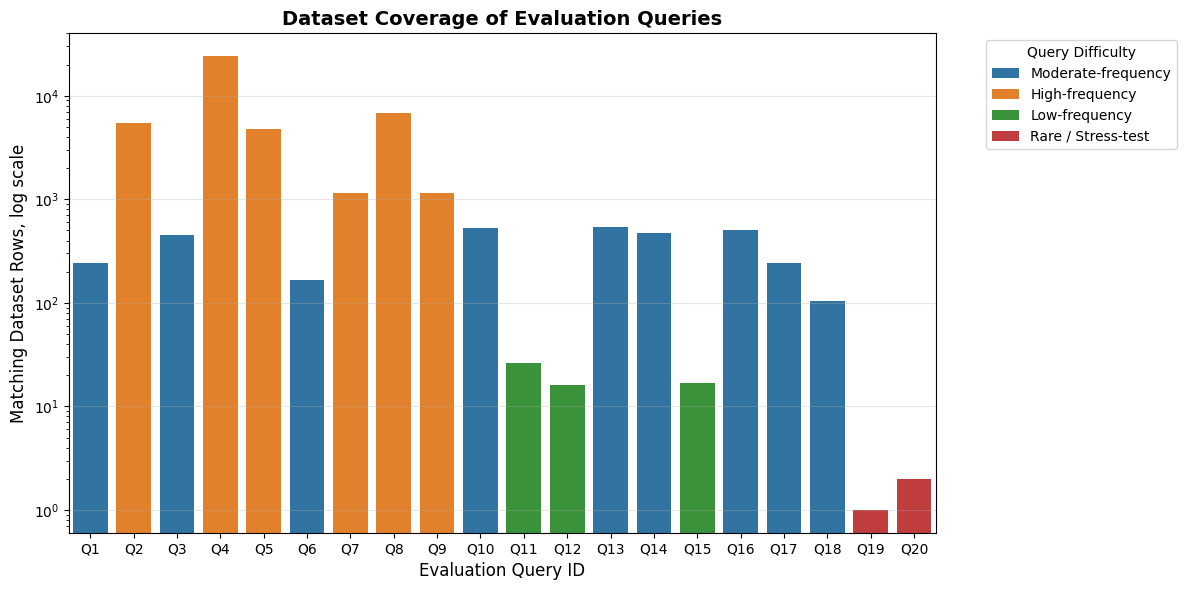

In [16]:
# Cell 11C: Plot query coverage distribution

plt.figure(figsize=(12, 6))

sns.barplot(
    data=query_validation_df,
    x="Query ID",
    y="Matching Dataset Rows",
    hue="Query Difficulty"
)

plt.yscale("log")
plt.title("Dataset Coverage of Evaluation Queries", fontsize=14, fontweight="bold")
plt.xlabel("Evaluation Query ID", fontsize=12)
plt.ylabel("Matching Dataset Rows, log scale", fontsize=12)
plt.legend(title="Query Difficulty", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [17]:
# Cell 11D: Save query validation table

query_validation_df.to_csv("query_validation_dataset_coverage.csv", index=False)

print(query_validation_df.to_csv(index=False))

Query ID,Query,Validation Terms,Matching Dataset Rows,Query Difficulty
Q1,Which fish species consume crustaceans in lotic habitats?,"crust, lotic",245,Moderate-frequency
Q2,Which fish consume aquatic insect larvae?,"insect, larvae",5397,High-frequency
Q3,Which fish species consume Odonata prey?,odonata,450,Moderate-frequency
Q4,What prey taxa are consumed in lentic habitats?,lentic,24171,High-frequency
Q5,Which fish consume plant-based prey?,plantae,4776,High-frequency
Q6,Which records describe fish feeding on zooplankton?,zooplankton,167,Moderate-frequency
Q7,Which fish consume chironomid larvae?,"chironom, larvae",1143,High-frequency
Q8,Which fish species consume terrestrial insects?,"terrestrial, insect",6876,High-frequency
Q9,What fish diets include algae?,algae,1147,High-frequency
Q10,Which fish feed on molluscan prey?,mollus,523,Moderate-frequency
Q11,Which fish species consume Araneae or spider-like prey in lake habitats?,"aranea, lake",26,Low-frequency
Q12,Which Salvelinus nama

In [18]:
# Cell 12: Chroma semantic retrieval function

def chroma_search(query, top_k=10):
    start_time = time.time()

    query_embedding = embedder.encode(
        [query],
        normalize_embeddings=True
    ).tolist()

    result = collection.query(
        query_embeddings=query_embedding,
        n_results=top_k,
        include=["documents", "metadatas", "distances"]
    )

    latency = time.time() - start_time

    rows = []
    for rank, (doc_id, doc, meta, dist) in enumerate(
        zip(
            result["ids"][0],
            result["documents"][0],
            result["metadatas"][0],
            result["distances"][0]
        ),
        start=1
    ):
        rows.append({
            "rank": rank,
            "id": doc_id,
            "distance": dist,
            "similarity_score": 1 - dist,
            "document": doc,
            **meta
        })

    return pd.DataFrame(rows), latency

In [19]:
# Cell 13: Test one semantic query

sample_query = "Which fish species consume crustaceans in lotic habitats?"

semantic_results, semantic_latency = chroma_search(sample_query, top_k=10)

print("Query:", sample_query)
print("Retrieval latency:", round(semantic_latency, 4), "seconds")

semantic_results[
    ["rank", "similarity_score", "fish_species", "prey_taxon", "prey_class", "habitat", "diet_percent"]
]

Query: Which fish species consume crustaceans in lotic habitats?
Retrieval latency: 0.1386 seconds


,rank,similarity_score,fish_species,prey_taxon,prey_class,habitat,diet_percent
0,1,0.512052,Notropis biguttatus,crustacea remains,not_reported,lotic,0.3
1,2,0.506548,Notropis biguttatus,crustacea remains,not_reported,lotic,0.0
2,3,0.460206,Notropis longirostris,crustacea,not_reported,lotic,0.8
3,4,0.459867,Notropis longirostris,crustacea,not_reported,lotic,0.4
4,5,0.459867,Notropis longirostris,crustacea,not_reported,lotic,0.4
5,6,0.459867,Notropis longirostris,crustacea,not_reported,lotic,0.4
6,7,0.459867,Notropis longirostris,crustacea,not_reported,lotic,0.4
7,8,0.459687,Notropis longirostris,crustacea,not_reported,lotic,5.3
8,9,0.459298,Notopterus notopterus,crustacea,not_reported,reservoir,40.0
9,10,0.459065,Notropis longirostris,crustacea,not_reported,lotic,0.6


In [20]:
# Cell 14: BM25 keyword baseline

def simple_tokenize(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z0-9_]+", " ", text)
    return text.split()

tokenized_docs = [simple_tokenize(doc) for doc in tqdm(documents)]

bm25 = BM25Okapi(tokenized_docs)

print("BM25 index prepared for", len(tokenized_docs), "documents.")

100%|██████████| 54750/54750 [00:01<00:00, 30645.26it/s]


BM25 index prepared for 54750 documents.


In [21]:
# Cell 15: BM25 search function

def bm25_search(query, top_k=10):
    start_time = time.time()

    tokenized_query = simple_tokenize(query)
    scores = bm25.get_scores(tokenized_query)

    top_indices = np.argsort(scores)[::-1][:top_k]
    latency = time.time() - start_time

    rows = []
    for rank, idx in enumerate(top_indices, start=1):
        row = df.iloc[idx]
        meta = metadatas[idx]

        rows.append({
            "rank": rank,
            "id": ids[idx],
            "bm25_score": scores[idx],
            "document": documents[idx],
            **meta
        })

    return pd.DataFrame(rows), latency

In [22]:
# Cell 16: Relevance judgment function

def is_relevant_row(row, must_contain):
    searchable_text = " ".join([
        str(row.get("document", "")),
        str(row.get("fish_species", "")),
        str(row.get("prey_taxon", "")),
        str(row.get("prey_class", "")),
        str(row.get("prey_kingdom", "")),
        str(row.get("prey_origin", "")),
        str(row.get("prey_stage", "")),
        str(row.get("habitat", ""))
    ]).lower()

    return int(all(term.lower() in searchable_text for term in must_contain))

In [23]:
# Cell 17: Retrieval metrics

def compute_retrieval_metrics(results_df, must_contain, k=10):
    temp = results_df.head(k).copy()
    temp["relevant"] = temp.apply(lambda row: is_relevant_row(row, must_contain), axis=1)

    relevance = temp["relevant"].values

    precision_at_k = relevance.sum() / k
    hit_rate_at_k = int(relevance.sum() > 0)

    reciprocal_rank = 0
    for i, rel in enumerate(relevance, start=1):
        if rel == 1:
            reciprocal_rank = 1 / i
            break

    try:
        ndcg_at_k = ndcg_score([relevance], [np.arange(k, 0, -1)])
    except:
        ndcg_at_k = 0

    return {
        f"Precision@{k}": precision_at_k,
        f"HitRate@{k}": hit_rate_at_k,
        "MRR": reciprocal_rank,
        f"nDCG@{k}": ndcg_at_k,
        "Relevant Retrieved": int(relevance.sum())
    }

In [24]:
# Cell 17A: Install and load additional embedding models

#!pip install -q FlagEmbedding

#import torch
#from FlagEmbedding import BGEM3FlagModel
#from sentence_transformers import SentenceTransformer

extra_embedding_models = {}

# Model 1: BGE-M3
print("Loading BAAI/bge-m3...")
bge_m3_model = BGEM3FlagModel(
    "BAAI/bge-m3",
    use_fp16=torch.cuda.is_available()
)
extra_embedding_models["BGE-M3"] = bge_m3_model

# Model 2: Nomic Embed Text v1.5
print("Loading nomic-ai/nomic-embed-text-v1.5...")
nomic_model = SentenceTransformer(
    "nomic-ai/nomic-embed-text-v1.5",
    trust_remote_code=True
)
extra_embedding_models["Nomic-v1.5"] = nomic_model

print("Additional embedding models loaded.")

Loading BAAI/bge-m3...


config.json:   0%|          | 0.00/687 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/444 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/695 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/286 [00:00<?, ?B/s]

Additional embedding models loaded.


In [25]:
# Cell 17B: Build additional Chroma collections

extra_collections = {}

def build_extra_chroma_collection(method_name, model, documents, metadatas, ids, batch_size=256):
    collection_name = method_name.lower().replace("-", "_").replace(".", "_") + "_collection"

    try:
        client.delete_collection(collection_name)
    except:
        pass

    new_collection = client.create_collection(name=collection_name)

    start_time = time.time()

    for start_idx in tqdm(range(0, len(documents), batch_size), desc=f"Indexing {method_name}"):
        end_idx = start_idx + batch_size

        batch_docs_raw = documents[start_idx:end_idx]
        batch_ids = ids[start_idx:end_idx]
        batch_meta = metadatas[start_idx:end_idx]

        if method_name == "BGE-M3":
            embeddings = model.encode(
                batch_docs_raw,
                batch_size=12,
                max_length=512
            )["dense_vecs"]

        elif method_name == "Nomic-v1.5":
            prefixed_docs = ["search_document: " + str(x) for x in batch_docs_raw]
            embeddings = model.encode(
                prefixed_docs,
                batch_size=32,
                normalize_embeddings=True,
                show_progress_bar=False
            )

        embeddings = np.asarray(embeddings).tolist()

        new_collection.add(
            ids=batch_ids,
            documents=batch_docs_raw,
            metadatas=batch_meta,
            embeddings=embeddings
        )

    total_time = time.time() - start_time

    print(f"{method_name} indexing completed.")
    print("Collection:", collection_name)
    print("Records indexed:", new_collection.count())
    print("Indexing time:", round(total_time, 2), "seconds")

    return new_collection, total_time


extra_indexing_times = {}

for method_name, model in extra_embedding_models.items():
    col, idx_time = build_extra_chroma_collection(
        method_name=method_name,
        model=model,
        documents=documents,
        metadatas=metadatas,
        ids=ids,
        batch_size=256
    )

    extra_collections[method_name] = col
    extra_indexing_times[method_name] = idx_time

pre tokenize: 100%|██████████| 22/22 [00:00<00:00, 251.60it/s]

pre tokenize: 100%|██████████| 22/22 [00:00<00:00, 334.59it/s]

pre tokenize: 100%|██████████| 22/22 [00:00<00:00, 437.92it/s]

pre tokenize: 100%|██████████| 22/22 [00:00<00:00, 460.38it/s]

pre tokenize: 100%|██████████| 22/22 [00:00<00:00, 409.61it/s]

pre tokenize: 100%|██████████| 22/22 [00:00<00:00, 444.75it/s]

pre tokenize: 100%|██████████| 22/22 [00:00<00:00, 457.88it/s]

pre tokenize: 100%|██████████| 22/22 [00:00<00:00, 447.37it/s]

pre tokenize: 100%|██████████| 22/22 [00:00<00:00, 262.81it/s]

pre tokenize: 100%|██████████| 22/22 [00:00<00:00, 419.42it/s]

pre tokenize: 100%|██████████| 22/22 [00:00<00:00, 434.21it/s]

pre tokenize: 100%|██████████| 22/22 [00:00<00:00, 437.70it/s]

pre tokenize: 100%|██████████| 22/22 [00:00<00:00, 453.88it/s]

pre tokenize: 100%|██████████| 22/22 [00:00<00:00, 439.17it/s]

pre tokenize: 100%|██████████| 22/22 [00:00<00:00, 441.71it/s]

pre tokenize: 100%|██████████| 22/22 [00

BGE-M3 indexing completed.
Collection: bge_m3_collection
Records indexed: 54750
Indexing time: 341.86 seconds


Indexing Nomic-v1.5: 100%|██████████| 214/214 [09:25<00:00,  2.64s/it]

Nomic-v1.5 indexing completed.
Collection: nomic_v1_5_collection
Records indexed: 54750
Indexing time: 565.59 seconds


In [26]:
# Cell 17C: Search function for additional embedding methods

def extra_embedding_search(query, method_name, top_k=10):
    start_time = time.time()

    model = extra_embedding_models[method_name]
    col = extra_collections[method_name]

    if method_name == "BGE-M3":
        query_embedding = model.encode(
            [query],
            batch_size=1,
            max_length=512
        )["dense_vecs"]

    elif method_name == "Nomic-v1.5":
        query_embedding = model.encode(
            ["search_query: " + query],
            normalize_embeddings=True,
            show_progress_bar=False
        )

    result = col.query(
        query_embeddings=np.asarray(query_embedding).tolist(),
        n_results=top_k,
        include=["documents", "metadatas", "distances"]
    )

    latency = time.time() - start_time

    rows = []
    for rank, (doc_id, doc, meta, dist) in enumerate(
        zip(
            result["ids"][0],
            result["documents"][0],
            result["metadatas"][0],
            result["distances"][0]
        ),
        start=1
    ):
        rows.append({
            "rank": rank,
            "id": doc_id,
            "distance": dist,
            "similarity_score": 1 - dist,
            "document": doc,
            **meta
        })

    return pd.DataFrame(rows), latency

In [27]:
# Cell 18: Run retrieval evaluation with BM25, MiniLM-Chroma, BGE-M3, and Nomic-v1.5

evaluation_records = []
retrieved_examples = {}

TOP_K = 10

for item in tqdm(evaluation_queries):
    qid = item["query_id"]
    query = item["query"]
    must_contain = item["must_contain"]

    # MiniLM-Chroma
    chroma_df, chroma_latency = chroma_search(query, top_k=TOP_K)
    chroma_metrics = compute_retrieval_metrics(chroma_df, must_contain, k=TOP_K)

    evaluation_records.append({
        "Query ID": qid,
        "Query": query,
        "Method": "MiniLM-Chroma",
        "Latency Seconds": chroma_latency,
        **chroma_metrics
    })

    retrieved_examples[(qid, "MiniLM-Chroma")] = chroma_df

    # BM25
    bm25_df, bm25_latency = bm25_search(query, top_k=TOP_K)
    bm25_metrics = compute_retrieval_metrics(bm25_df, must_contain, k=TOP_K)

    evaluation_records.append({
        "Query ID": qid,
        "Query": query,
        "Method": "BM25",
        "Latency Seconds": bm25_latency,
        **bm25_metrics
    })

    retrieved_examples[(qid, "BM25")] = bm25_df

    # BGE-M3 and Nomic-v1.5
    for method_name in ["BGE-M3", "Nomic-v1.5"]:
        extra_df, extra_latency = extra_embedding_search(
            query=query,
            method_name=method_name,
            top_k=TOP_K
        )

        extra_metrics = compute_retrieval_metrics(extra_df, must_contain, k=TOP_K)

        evaluation_records.append({
            "Query ID": qid,
            "Query": query,
            "Method": method_name,
            "Latency Seconds": extra_latency,
            **extra_metrics
        })

        retrieved_examples[(qid, method_name)] = extra_df

retrieval_eval_df = pd.DataFrame(evaluation_records)

retrieval_eval_df

pre tokenize: 100%|██████████| 1/1 [00:00<00:00, 1698.79it/s]

pre tokenize: 100%|██████████| 1/1 [00:00<00:00, 670.12it/s]

pre tokenize: 100%|██████████| 1/1 [00:00<00:00, 2054.02it/s]

pre tokenize: 100%|██████████| 1/1 [00:00<00:00, 2015.52it/s]

pre tokenize: 100%|██████████| 1/1 [00:00<00:00, 2117.27it/s]

pre tokenize: 100%|██████████| 1/1 [00:00<00:00, 799.37it/s]

pre tokenize: 100%|██████████| 1/1 [00:00<00:00, 2478.90it/s]

pre tokenize: 100%|██████████| 1/1 [00:00<00:00, 2115.13it/s]

pre tokenize: 100%|██████████| 1/1 [00:00<00:00, 1440.85it/s]

pre tokenize: 100%|██████████| 1/1 [00:00<00:00, 1685.81it/s]

pre tokenize: 100%|██████████| 1/1 [00:00<00:00, 1956.30it/s]

pre tokenize: 100%|██████████| 1/1 [00:00<00:00, 1022.25it/s]

pre tokenize: 100%|██████████| 1/1 [00:00<00:00, 1926.64it/s]

pre tokenize: 100%|██████████| 1/1 [00:00<00:00, 1189.87it/s]

pre tokenize: 100%|██████████| 1/1 [00:00<00:00, 2186.81it/s]

pre tokenize: 100%|██████████| 1/1 [00:00<00:00, 2169.84i

,Query ID,Query,Method,Latency Seconds,Precision@10,HitRate@10,MRR,nDCG@10,Relevant Retrieved
0,Q1,Which fish species consume crustaceans in loti...,MiniLM-Chroma,0.018620,0.9,1,1.000000,0.997188,9
1,Q1,Which fish species consume crustaceans in loti...,BM25,0.130241,0.0,0,0.000000,0.000000,0
2,Q1,Which fish species consume crustaceans in loti...,BGE-M3,0.106411,0.0,0,0.000000,0.000000,0
3,Q1,Which fish species consume crustaceans in loti...,Nomic-v1.5,0.024180,0.0,0,0.000000,0.000000,0
4,Q2,Which fish consume aquatic insect larvae?,MiniLM-Chroma,0.011449,1.0,1,1.000000,1.000000,10
...,...,...,...,...,...,...,...,...,...
75,Q19,Which records describe Lepomis macrochirus con...,Nomic-v1.5,0.018877,0.1,1,0.125000,0.315465,1
76,Q20,Which Poropanchax normani records contain misc...,MiniLM-Chroma,0.014180,0.0,0,0.000000,0.000000,0
77,Q20,Which Poropanchax normani records contain misc...,BM25,0.106749,0.2,1,1.000000,1.000000,2
78,Q20,Which Poropanchax normani records contain misc...,BGE-M3,0.057183,0.2,1,0.166667,0.395647,2


In [28]:
# Cell 19: Mean retrieval performance table

retrieval_summary = retrieval_eval_df.groupby("Method").agg({
    "Precision@10": ["mean", "std"],
    "HitRate@10": ["mean", "std"],
    "MRR": ["mean", "std"],
    "nDCG@10": ["mean", "std"],
    "Latency Seconds": ["mean", "std"]
}).reset_index()

retrieval_summary.columns = [
    "Method",
    "Precision@10 Mean", "Precision@10 SD",
    "HitRate@10 Mean", "HitRate@10 SD",
    "MRR Mean", "MRR SD",
    "nDCG@10 Mean", "nDCG@10 SD",
    "Latency Mean Seconds", "Latency SD Seconds"
]

retrieval_summary

,Method,Precision@10 Mean,Precision@10 SD,HitRate@10 Mean,HitRate@10 SD,MRR Mean,MRR SD,nDCG@10 Mean,nDCG@10 SD,Latency Mean Seconds,Latency SD Seconds
0,BGE-M3,0.31,0.341668,0.70,0.470162,0.591667,0.475957,0.614075,0.451240,0.067385,0.015138
1,BM25,0.64,0.460435,0.80,0.410391,0.755000,0.435860,0.764453,0.422759,0.138687,0.046868
2,MiniLM-Chroma,0.61,0.394568,0.85,0.366348,0.707917,0.422637,0.752853,0.375113,0.022405,0.010060
3,Nomic-v1.5,0.47,0.447331,0.65,0.489360,0.562500,0.497527,0.569326,0.466514,0.022633,0.003827


In [29]:
# Cell 19A: Sort retrieval summary by nDCG and latency

retrieval_summary_sorted = retrieval_summary.sort_values(
    by=["nDCG@10 Mean", "Latency Mean Seconds"],
    ascending=[False, True]
)

retrieval_summary_sorted

,Method,Precision@10 Mean,Precision@10 SD,HitRate@10 Mean,HitRate@10 SD,MRR Mean,MRR SD,nDCG@10 Mean,nDCG@10 SD,Latency Mean Seconds,Latency SD Seconds
1,BM25,0.64,0.460435,0.80,0.410391,0.755000,0.435860,0.764453,0.422759,0.138687,0.046868
2,MiniLM-Chroma,0.61,0.394568,0.85,0.366348,0.707917,0.422637,0.752853,0.375113,0.022405,0.010060
0,BGE-M3,0.31,0.341668,0.70,0.470162,0.591667,0.475957,0.614075,0.451240,0.067385,0.015138
3,Nomic-v1.5,0.47,0.447331,0.65,0.489360,0.562500,0.497527,0.569326,0.466514,0.022633,0.003827


In [30]:
# Cell 20: Copy-pasteable CSV table

print(retrieval_summary.to_csv(index=False))

Method,Precision@10 Mean,Precision@10 SD,HitRate@10 Mean,HitRate@10 SD,MRR Mean,MRR SD,nDCG@10 Mean,nDCG@10 SD,Latency Mean Seconds,Latency SD Seconds
BGE-M3,0.31,0.34166773641253156,0.7,0.4701623459816272,0.5916666666666667,0.4759570229750773,0.6140749919223231,0.4512399279530141,0.06738514900207519,0.015137628962689503
BM25,0.64,0.46043457732885357,0.8,0.41039134083406165,0.755,0.4358597070279912,0.7644532413158943,0.42275931379740794,0.1386873245239258,0.046868173902225335
MiniLM-Chroma,0.6100000000000001,0.3945683851074688,0.85,0.36634754853252327,0.7079166666666666,0.42263683378860134,0.7528530460985092,0.3751127495571331,0.022404944896697997,0.010059752391258269
Nomic-v1.5,0.47000000000000003,0.44733126780708576,0.65,0.48936048492959294,0.5625,0.49752677790933236,0.5693260083220918,0.4665141648729628,0.022633349895477294,0.003826531863544396



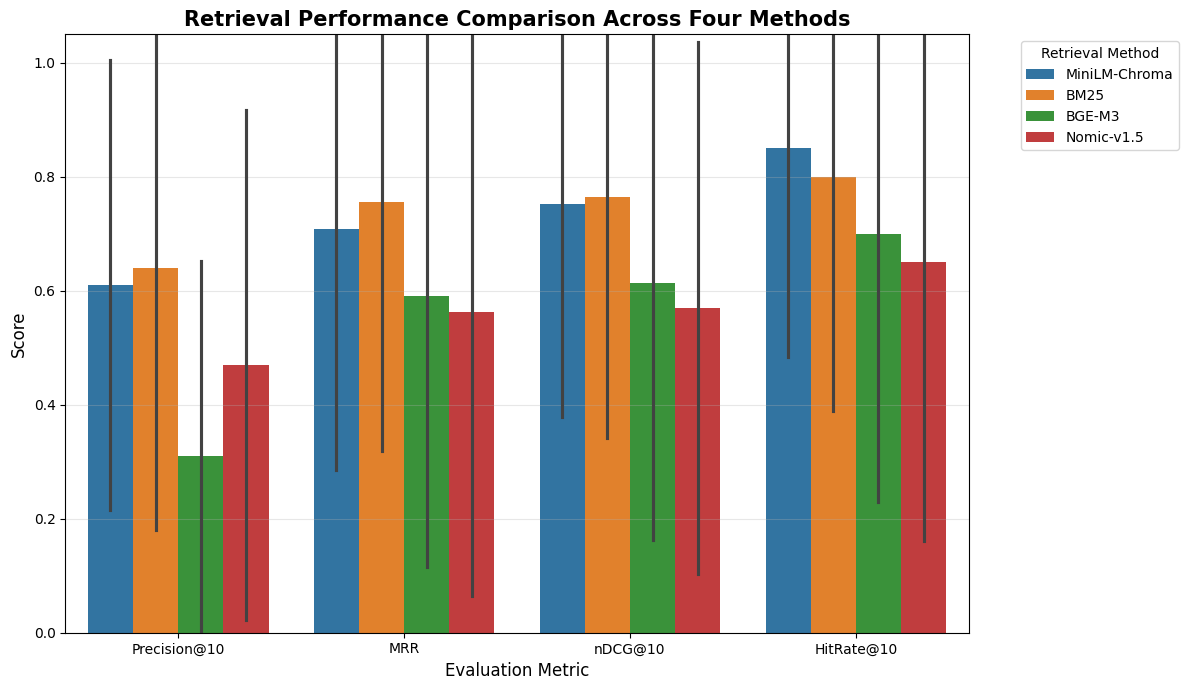

In [31]:
# Cell 21 updated: Retrieval performance bar plot for all methods

plot_df = retrieval_eval_df.melt(
    id_vars=["Query ID", "Method"],
    value_vars=["Precision@10", "MRR", "nDCG@10", "HitRate@10"],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(12, 7))

sns.barplot(
    data=plot_df,
    x="Metric",
    y="Score",
    hue="Method",
    errorbar="sd"
)

plt.title("Retrieval Performance Comparison Across Four Methods", fontsize=15, fontweight="bold")
plt.xlabel("Evaluation Metric", fontsize=12)
plt.ylabel("Score", fontsize=12)
plt.ylim(0, 1.05)
plt.legend(title="Retrieval Method", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

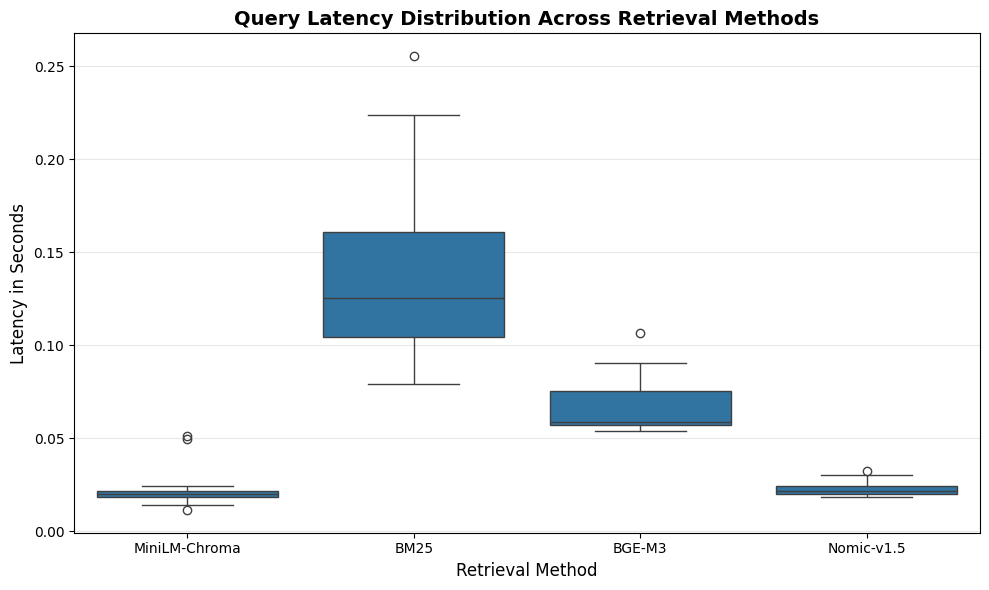

In [32]:
# Cell 22: Query latency plot

plt.figure(figsize=(10, 6))
sns.boxplot(data=retrieval_eval_df, x="Method", y="Latency Seconds")

plt.title("Query Latency Distribution Across Retrieval Methods", fontsize=14, fontweight="bold")
plt.xlabel("Retrieval Method", fontsize=12)
plt.ylabel("Latency in Seconds", fontsize=12)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [63]:
# Cell 23: Enriched statistical tests for embedding / retrieval models

from scipy.stats import (
    ttest_rel,
    wilcoxon,
    shapiro,
    normaltest,
    skew,
    kurtosis,
    pearsonr,
    spearmanr,
    bootstrap
)

import numpy as np
import pandas as pd

retrieval_stat_records = []

baseline_method = "MiniLM-Chroma"

retrieval_metrics = [
    "Precision@10",
    "HitRate@10",
    "MRR",
    "nDCG@10",
    "Latency Seconds"
]

comparison_methods = [
    m for m in retrieval_eval_df["Method"].unique()
    if m != baseline_method
]

def paired_cohens_d(diff):
    sd = np.std(diff, ddof=1)
    return np.mean(diff) / sd if sd != 0 else np.nan

def hedges_g_from_d(d, n):
    if n <= 1 or np.isnan(d):
        return np.nan
    correction = 1 - (3 / (4*n - 9))
    return d * correction

def rank_biserial_from_wilcoxon(w_stat, n):
    if np.isnan(w_stat):
        return np.nan
    total_rank_sum = n * (n + 1) / 2
    return 1 - (2 * w_stat / total_rank_sum)

def cliffs_delta_paired(x, y):
    greater = np.sum(x > y)
    lesser = np.sum(x < y)
    n = len(x)
    return (greater - lesser) / n if n > 0 else np.nan

def mean_ci_bootstrap(diff, confidence_level=0.95, n_resamples=5000):
    try:
        res = bootstrap(
            (diff,),
            np.mean,
            confidence_level=confidence_level,
            n_resamples=n_resamples,
            method="percentile",
            random_state=42
        )
        return res.confidence_interval.low, res.confidence_interval.high
    except:
        return np.nan, np.nan

for compared_method in comparison_methods:

    for metric in retrieval_metrics:

        baseline_values = retrieval_eval_df[
            retrieval_eval_df["Method"] == baseline_method
        ].sort_values("Query ID")[metric].values.astype(float)

        compared_values = retrieval_eval_df[
            retrieval_eval_df["Method"] == compared_method
        ].sort_values("Query ID")[metric].values.astype(float)

        diff = baseline_values - compared_values
        n = len(diff)

        baseline_mean = np.mean(baseline_values)
        baseline_sd = np.std(baseline_values, ddof=1)

        compared_mean = np.mean(compared_values)
        compared_sd = np.std(compared_values, ddof=1)

        diff_mean = np.mean(diff)
        diff_median = np.median(diff)
        diff_sd = np.std(diff, ddof=1)
        diff_min = np.min(diff)
        diff_max = np.max(diff)

        try:
            diff_skew = skew(diff, bias=False)
        except:
            diff_skew = np.nan

        try:
            diff_kurtosis = kurtosis(diff, bias=False)
        except:
            diff_kurtosis = np.nan

        try:
            shapiro_stat, shapiro_p = shapiro(diff)
        except:
            shapiro_stat, shapiro_p = np.nan, np.nan

        try:
            dagostino_stat, dagostino_p = normaltest(diff)
        except:
            dagostino_stat, dagostino_p = np.nan, np.nan

        try:
            t_stat, t_p = ttest_rel(baseline_values, compared_values)
        except:
            t_stat, t_p = np.nan, np.nan

        try:
            w_stat, w_p = wilcoxon(baseline_values, compared_values, zero_method="wilcox")
        except:
            w_stat, w_p = np.nan, np.nan

        cohen_d = paired_cohens_d(diff)
        hedges_g = hedges_g_from_d(cohen_d, n)
        rank_biserial = rank_biserial_from_wilcoxon(w_stat, n)
        cliffs_delta = cliffs_delta_paired(baseline_values, compared_values)

        ci_low, ci_high = mean_ci_bootstrap(diff)

        try:
            pearson_r, pearson_p = pearsonr(baseline_values, compared_values)
        except:
            pearson_r, pearson_p = np.nan, np.nan

        try:
            spearman_r, spearman_p = spearmanr(baseline_values, compared_values)
        except:
            spearman_r, spearman_p = np.nan, np.nan

        baseline_wins = int(np.sum(baseline_values > compared_values))
        compared_wins = int(np.sum(compared_values > baseline_values))
        ties = int(np.sum(baseline_values == compared_values))

        retrieval_stat_records.append({
            "Baseline Method": baseline_method,
            "Compared Method": compared_method,
            "Metric": metric,
            "N Queries": n,

            "Baseline Mean": baseline_mean,
            "Baseline SD": baseline_sd,
            "Compared Mean": compared_mean,
            "Compared SD": compared_sd,

            "Mean Difference Baseline-Compared": diff_mean,
            "Median Difference Baseline-Compared": diff_median,
            "Difference SD": diff_sd,
            "Difference Min": diff_min,
            "Difference Max": diff_max,
            "Difference Skewness": diff_skew,
            "Difference Kurtosis": diff_kurtosis,

            "Bootstrap 95% CI Low": ci_low,
            "Bootstrap 95% CI High": ci_high,

            "Shapiro W": shapiro_stat,
            "Shapiro p": shapiro_p,
            "DAgostino K2": dagostino_stat,
            "DAgostino p": dagostino_p,

            "Paired t statistic": t_stat,
            "Paired t-test p": t_p,
            "Wilcoxon statistic": w_stat,
            "Wilcoxon p": w_p,

            "Paired Cohen d": cohen_d,
            "Hedges g": hedges_g,
            "Rank-biserial correlation": rank_biserial,
            "Paired Cliff delta": cliffs_delta,

            "Pearson r": pearson_r,
            "Pearson p": pearson_p,
            "Spearman rho": spearman_r,
            "Spearman p": spearman_p,

            "Baseline Wins": baseline_wins,
            "Compared Wins": compared_wins,
            "Ties": ties
        })

embedding_stat_tests_df = pd.DataFrame(retrieval_stat_records)

pd.set_option("display.max_columns", None)
embedding_stat_tests_df

,Baseline Method,Compared Method,Metric,N Queries,Baseline Mean,Baseline SD,Compared Mean,Compared SD,Mean Difference Baseline-Compared,Median Difference Baseline-Compared,Difference SD,Difference Min,Difference Max,Difference Skewness,Difference Kurtosis,Bootstrap 95% CI Low,Bootstrap 95% CI High,Shapiro W,Shapiro p,DAgostino K2,DAgostino p,Paired t statistic,Paired t-test p,Wilcoxon statistic,Wilcoxon p,Paired Cohen d,Hedges g,Rank-biserial correlation,Paired Cliff delta,Pearson r,Pearson p,Spearman rho,Spearman p,Baseline Wins,Compared Wins,Ties
0,MiniLM-Chroma,BM25,Precision@10,20,0.610000,0.394568,0.640000,0.460435,-0.030000,0.000000,0.547819,-1.000000,1.000000,0.329997,-0.181220,-0.265000,0.205000,0.901785,0.044547,0.461268,0.794030,-0.244906,8.091548e-01,37.0,0.874995,-0.054763,-0.052449,0.647619,-0.20,0.185991,0.432392,0.226028,0.337952,4,8,8
1,MiniLM-Chroma,BM25,HitRate@10,20,0.850000,0.366348,0.800000,0.410391,0.050000,0.000000,0.510418,-1.000000,1.000000,0.112142,1.648931,-0.150000,0.250000,0.688342,0.000028,2.402043,0.300887,0.438086,6.662641e-01,6.0,0.654721,0.097959,0.093820,0.942857,0.05,0.140028,0.555985,0.140028,0.555985,3,2,15
2,MiniLM-Chroma,BM25,MRR,20,0.707917,0.422637,0.755000,0.435860,-0.047083,0.000000,0.605489,-1.000000,1.000000,0.150630,-0.188759,-0.310833,0.208781,0.849085,0.005146,0.097624,0.952360,-0.347757,7.318458e-01,22.0,0.951915,-0.077761,-0.074475,0.790476,-0.05,0.005369,0.982077,0.016373,0.945378,4,5,11
3,MiniLM-Chroma,BM25,nDCG@10,20,0.752853,0.375113,0.764453,0.422759,-0.011600,0.000000,0.568069,-1.000000,1.000000,0.276989,0.200618,-0.259163,0.233244,0.876978,0.015618,0.522204,0.770203,-0.091323,9.281921e-01,35.0,0.752762,-0.020420,-0.019558,0.666667,-0.20,-0.010302,0.965617,0.003657,0.987790,4,8,8
4,MiniLM-Chroma,BM25,Latency Seconds,20,0.022405,0.010060,0.138687,0.046868,-0.116282,-0.099051,0.048900,-0.236807,-0.048461,-0.981446,0.662440,-0.137702,-0.096104,0.928810,0.146483,4.338097,0.114286,-10.634480,1.936364e-09,0.0,0.000002,-2.377942,-2.277466,1.000000,-1.00,-0.099079,0.677712,0.040602,0.865047,0,20,0
5,MiniLM-Chroma,BGE-M3,Precision@10,20,0.610000,0.394568,0.310000,0.341668,0.300000,0.300000,0.535085,-1.000000,1.000000,-0.858852,0.545056,0.060000,0.515000,0.923667,0.116587,3.418839,0.180971,2.507342,2.140636e-02,25.5,0.027688,0.560659,0.536969,0.757143,0.50,-0.051534,0.829167,0.049961,0.834310,13,3,4
6,MiniLM-Chroma,BGE-M3,HitRate@10,20,0.850000,0.366348,0.700000,0.470162,0.150000,0.000000,0.587143,-1.000000,1.000000,-0.004334,0.177580,-0.100000,0.400000,0.754342,0.000194,0.176123,0.915705,1.142516,2.674331e-01,8.0,0.256839,0.255474,0.244680,0.923810,0.15,0.030557,0.898241,0.030557,0.898241,5,2,13
7,MiniLM-Chroma,BGE-M3,MRR,20,0.707917,0.422637,0.591667,0.475957,0.116250,0.000000,0.571333,-1.000000,1.000000,-0.103013,-0.122499,-0.121292,0.361667,0.894849,0.033052,0.054559,0.973089,0.909952,3.742474e-01,22.5,0.347895,0.203471,0.194874,0.785714,0.15,0.195706,0.408287,0.190859,0.420221,7,4,9
8,MiniLM-Chroma,BGE-M3,nDCG@10,20,0.752853,0.375113,0.614075,0.451240,0.138778,0.007891,0.542544,-1.000000,1.000000,-0.054851,-0.167563,-0.094093,0.369799,0.928932,0.147273,0.014653,0.992701,1.143934,2.668592e-01,38.5,0.221948,0.255791,0.244983,0.633333,0.25,0.147617,0.534551,0.227650,0.334404,10,5,5
9,MiniLM-Chroma,BGE-M3,Latency Seconds,20,0.022405,0.010060,0.067385,0.015138,-0.044980,-0.041644,0.018786,-0.087791,-0.003608,-0.216656,0.820835,-0.053013,-0.036994,0.973784,0.831882,1.167484,0.557807,-10.707954,1.729476e-09,0.0,0.000002,-2.394371,-2.293201,1.000000,-1.00,-0.074074,0.756282,-0.264662,0.259469,0,20,0


In [64]:
# Corrected Cell 24A: Import torch and check device

import torch

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

device_id = 0 if torch.cuda.is_available() else -1
print("Using device:", "GPU" if device_id == 0 else "CPU")

Torch version: 2.10.0+cu128
CUDA available: True
Using device: GPU


In [35]:
#Corrected Cell 24: Load BART summarizer

import time
import torch
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

summarizer_model_name = "facebook/bart-large-cnn"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

start = time.time()

bart_tokenizer = AutoTokenizer.from_pretrained(summarizer_model_name)
bart_model = AutoModelForSeq2SeqLM.from_pretrained(summarizer_model_name).to(device)
bart_model.eval()

summarizer_load_time = time.time() - start

print("Loaded summarizer:", summarizer_model_name)
print("Device:", device)
print("Summarizer load time:", round(summarizer_load_time, 2), "seconds")

config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

Please make sure the generation config includes `forced_bos_token_id=0`. 


Loading weights:   0%|          | 0/511 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

Loaded summarizer: facebook/bart-large-cnn
Device: cuda
Summarizer load time: 61.35 seconds


In [37]:
#Cell 25: RAG summary function

def generate_rag_summary(query, retrieved_df, max_records=5):
    evidence_text = " ".join(
        retrieved_df.head(max_records)["document"].astype(str).tolist()
    )

    evidence_text = evidence_text[:3500]

    prompt_text = (
        f"Question: {query}. "
        f"Evidence from freshwater fish diet records: {evidence_text}"
    )

    start_time = time.time()

    inputs = bart_tokenizer(
        prompt_text,
        max_length=1024,
        truncation=True,
        return_tensors="pt"
    ).to(device)

    with torch.no_grad():
        summary_ids = bart_model.generate(
            inputs["input_ids"],
            attention_mask=inputs["attention_mask"],
            max_length=160,
            min_length=50,
            num_beams=4,
            early_stopping=True,
            no_repeat_ngram_size=3
        )

    summary_text = bart_tokenizer.decode(
        summary_ids[0],
        skip_special_tokens=True
    )

    latency = time.time() - start_time

    return summary_text, latency, evidence_text

In [38]:
# Cell 26: Generate summaries for all queries

summary_records = []

for item in tqdm(evaluation_queries):
    qid = item["query_id"]
    query = item["query"]

    retrieved_df = retrieved_examples[(qid, "MiniLM-Chroma")]

    summary_text, summary_latency, evidence_text = generate_rag_summary(
        query,
        retrieved_df,
        max_records=5
    )

    summary_records.append({
        "Query ID": qid,
        "Query": query,
        "Generated Summary": summary_text,
        "Evidence Length Words": len(evidence_text.split()),
        "Summary Length Words": len(summary_text.split()),
        "Compression Ratio": len(summary_text.split()) / max(len(evidence_text.split()), 1),
        "Summarization Latency Seconds": summary_latency
    })

summary_eval_df = pd.DataFrame(summary_records)

summary_eval_df

100%|██████████| 20/20 [00:21<00:00,  1.06s/it]


,Query ID,Query,Generated Summary,Evidence Length Words,Summary Length Words,Compression Ratio,Summarization Latency Seconds
0,Q1,Which fish species consume crustaceans in loti...,Evidence from freshwater fish diet records: Fi...,274,50,0.182482,1.451878
1,Q2,Which fish consume aquatic insect larvae?,Fish species Salvelinus fontinalis consumed pr...,265,36,0.135849,0.913868
2,Q3,Which fish species consume Odonata prey?,Fish species Salmo trutta consumed prey taxon ...,268,36,0.134328,0.923579
3,Q4,What prey taxa are consumed in lentic habitats?,Fish species Protopterus annectens consumed pr...,271,38,0.140221,0.893243
4,Q5,Which fish consume plant-based prey?,Fish species Steindachnerina gracilis consumed...,286,42,0.146853,1.025444
5,Q6,Which records describe fish feeding on zooplan...,Fish species Ictalurus punctatus consumed prey...,270,36,0.133333,1.026133
6,Q7,Which fish consume chironomid larvae?,Fish species fasciatus consumed prey taxon chi...,273,39,0.142857,1.175534
7,Q8,Which fish species consume terrestrial insects?,Fish species Ancistrus sp. consumed prey taxon...,272,40,0.147059,1.191058
8,Q9,What fish diets include algae?,Fish species Mesopotamichthys sharpeyi consume...,291,41,0.140893,0.930518
9,Q10,Which fish feed on molluscan prey?,Fish species Barbus platydorsus consumed prey ...,270,36,0.133333,0.974554


In [39]:
# Cell 27: ROUGE evaluation using retrieved evidence as reference

rouge = rouge_scorer.RougeScorer(["rouge1", "rouge2", "rougeL"], use_stemmer=True)

rouge_records = []

for item in tqdm(evaluation_queries):
    qid = item["query_id"]
    query = item["query"]

    retrieved_df = retrieved_examples[(qid, "MiniLM-Chroma")]
    reference = " ".join(retrieved_df.head(5)["document"].astype(str).tolist())[:3500]

    generated = summary_eval_df[summary_eval_df["Query ID"] == qid]["Generated Summary"].iloc[0]

    scores = rouge.score(reference, generated)

    rouge_records.append({
        "Query ID": qid,
        "ROUGE-1 F1": scores["rouge1"].fmeasure,
        "ROUGE-2 F1": scores["rouge2"].fmeasure,
        "ROUGE-L F1": scores["rougeL"].fmeasure
    })

rouge_df = pd.DataFrame(rouge_records)

summary_eval_df = summary_eval_df.merge(rouge_df, on="Query ID")

summary_eval_df

100%|██████████| 20/20 [00:00<00:00, 112.48it/s]


,Query ID,Query,Generated Summary,Evidence Length Words,Summary Length Words,Compression Ratio,Summarization Latency Seconds,ROUGE-1 F1,ROUGE-2 F1,ROUGE-L F1
0,Q1,Which fish species consume crustaceans in loti...,Evidence from freshwater fish diet records: Fi...,274,50,0.182482,1.451878,0.283237,0.261628,0.271676
1,Q2,Which fish consume aquatic insect larvae?,Fish species Salvelinus fontinalis consumed pr...,265,36,0.135849,0.913868,0.229814,0.225000,0.229814
2,Q3,Which fish species consume Odonata prey?,Fish species Salmo trutta consumed prey taxon ...,268,36,0.134328,0.923579,0.229102,0.224299,0.229102
3,Q4,What prey taxa are consumed in lentic habitats?,Fish species Protopterus annectens consumed pr...,271,38,0.140221,0.893243,0.236364,0.219512,0.236364
4,Q5,Which fish consume plant-based prey?,Fish species Steindachnerina gracilis consumed...,286,42,0.146853,1.025444,0.241379,0.231214,0.241379
5,Q6,Which records describe fish feeding on zooplan...,Fish species Ictalurus punctatus consumed prey...,270,36,0.133333,1.026133,0.231707,0.220859,0.231707
6,Q7,Which fish consume chironomid larvae?,Fish species fasciatus consumed prey taxon chi...,273,39,0.142857,1.175534,0.250765,0.246154,0.244648
7,Q8,Which fish species consume terrestrial insects?,Fish species Ancistrus sp. consumed prey taxon...,272,40,0.147059,1.191058,0.246988,0.236364,0.246988
8,Q9,What fish diets include algae?,Fish species Mesopotamichthys sharpeyi consume...,291,41,0.140893,0.930518,0.242075,0.231884,0.242075
9,Q10,Which fish feed on molluscan prey?,Fish species Barbus platydorsus consumed prey ...,270,36,0.133333,0.974554,0.231707,0.220859,0.231707


In [40]:
# Cell 28: Summary evaluation table

summary_table = summary_eval_df[[
    "Query ID",
    "Evidence Length Words",
    "Summary Length Words",
    "Compression Ratio",
    "ROUGE-1 F1",
    "ROUGE-2 F1",
    "ROUGE-L F1",
    "Summarization Latency Seconds"
]]

summary_table

,Query ID,Evidence Length Words,Summary Length Words,Compression Ratio,ROUGE-1 F1,ROUGE-2 F1,ROUGE-L F1,Summarization Latency Seconds
0,Q1,274,50,0.182482,0.283237,0.261628,0.271676,1.451878
1,Q2,265,36,0.135849,0.229814,0.225000,0.229814,0.913868
2,Q3,268,36,0.134328,0.229102,0.224299,0.229102,0.923579
3,Q4,271,38,0.140221,0.236364,0.219512,0.236364,0.893243
4,Q5,286,42,0.146853,0.241379,0.231214,0.241379,1.025444
5,Q6,270,36,0.133333,0.231707,0.220859,0.231707,1.026133
6,Q7,273,39,0.142857,0.250765,0.246154,0.244648,1.175534
7,Q8,272,40,0.147059,0.246988,0.236364,0.246988,1.191058
8,Q9,291,41,0.140893,0.242075,0.231884,0.242075,0.930518
9,Q10,270,36,0.133333,0.231707,0.220859,0.231707,0.974554


In [46]:
# Cell 28A: Load T5 summarizer manually

import time
import torch
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

t5_model_name = "google-t5/t5-base"
# For lighter Colab use:
# t5_model_name = "google-t5/t5-small"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

start = time.time()

t5_tokenizer = AutoTokenizer.from_pretrained(t5_model_name)
t5_model = AutoModelForSeq2SeqLM.from_pretrained(t5_model_name).to(device)
t5_model.eval()

t5_load_time = time.time() - start

print("Loaded T5 summarizer:", t5_model_name)
print("Device:", device)
print("T5 load time:", round(t5_load_time, 2), "seconds")

config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/892M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/257 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

Loaded T5 summarizer: google-t5/t5-base
Device: cuda
T5 load time: 62.04 seconds


In [47]:
# Cell 28B: T5-based RAG summary function

def generate_t5_rag_summary(query, retrieved_df, max_records=5):
    evidence_text = " ".join(
        retrieved_df.head(max_records)["document"].astype(str).tolist()
    )

    evidence_text = evidence_text[:3500]

    prompt_text = (
        "summarize: "
        f"Question: {query}. "
        f"Evidence from freshwater fish diet records: {evidence_text}"
    )

    start_time = time.time()

    inputs = t5_tokenizer(
        prompt_text,
        max_length=1024,
        truncation=True,
        return_tensors="pt"
    ).to(device)

    with torch.no_grad():
        output_ids = t5_model.generate(
            inputs["input_ids"],
            attention_mask=inputs["attention_mask"],
            max_length=160,
            min_length=40,
            num_beams=4,
            early_stopping=True,
            no_repeat_ngram_size=3
        )

    summary_text = t5_tokenizer.decode(
        output_ids[0],
        skip_special_tokens=True
    )

    latency = time.time() - start_time

    return summary_text, latency, evidence_text

In [48]:
# Cell 28C: Generate T5 summaries for all queries

t5_summary_records = []

for item in tqdm(evaluation_queries):
    qid = item["query_id"]
    query = item["query"]

    retrieved_df = retrieved_examples[(qid, "MiniLM-Chroma")]

    summary_text, summary_latency, evidence_text = generate_t5_rag_summary(
        query,
        retrieved_df,
        max_records=5
    )

    t5_summary_records.append({
        "Query ID": qid,
        "Query": query,
        "Summarizer": "T5-base",
        "Generated Summary": summary_text,
        "Evidence Length Words": len(evidence_text.split()),
        "Summary Length Words": len(summary_text.split()),
        "Compression Ratio": len(summary_text.split()) / max(len(evidence_text.split()), 1),
        "Summarization Latency Seconds": summary_latency
    })

t5_summary_eval_df = pd.DataFrame(t5_summary_records)

t5_summary_eval_df

100%|██████████| 20/20 [00:26<00:00,  1.35s/it]


,Query ID,Query,Summarizer,Generated Summary,Evidence Length Words,Summary Length Words,Compression Ratio,Summarization Latency Seconds
0,Q1,Which fish species consume crustaceans in loti...,T5-base,fish species notropis biguttatus consumed prey...,274,33,0.120438,1.814926
1,Q2,Which fish consume aquatic insect larvae?,T5-base,fish species Salvelinus fontinalis consumed pr...,265,36,0.135849,1.405140
2,Q3,Which fish species consume Odonata prey?,T5-base,fish species Hepsetus odoe consumed prey taxon...,268,27,0.100746,1.516706
3,Q4,What prey taxa are consumed in lentic habitats?,T5-base,evidence from freshwater fish diet records . f...,271,32,0.118081,0.998756
4,Q5,Which fish consume plant-based prey?,T5-base,evidence from freshwater fish diet records . f...,286,35,0.122378,1.225881
5,Q6,Which records describe fish feeding on zooplan...,T5-base,fish species Ictalurus punctatus consumed prey...,270,33,0.122222,1.228795
6,Q7,Which fish consume chironomid larvae?,T5-base,fish species not reported consumed prey taxon ...,273,28,0.102564,1.327970
7,Q8,Which fish species consume terrestrial insects?,T5-base,fish species Ictalurus punctatus consumed prey...,272,34,0.125000,1.130879
8,Q9,What fish diets include algae?,T5-base,fish species consumed prey taxon algae from pr...,291,24,0.082474,1.232906
9,Q10,Which fish feed on molluscan prey?,T5-base,evidence from freshwater fish diet records . f...,270,27,0.100000,1.410871


In [49]:
# Cell 28D: Compute ROUGE scores for T5 summaries

t5_rouge_records = []

for item in tqdm(evaluation_queries):
    qid = item["query_id"]

    retrieved_df = retrieved_examples[(qid, "MiniLM-Chroma")]
    reference = " ".join(retrieved_df.head(5)["document"].astype(str).tolist())[:3500]

    generated = t5_summary_eval_df[
        t5_summary_eval_df["Query ID"] == qid
    ]["Generated Summary"].iloc[0]

    scores = rouge.score(reference, generated)

    t5_rouge_records.append({
        "Query ID": qid,
        "ROUGE-1 F1": scores["rouge1"].fmeasure,
        "ROUGE-2 F1": scores["rouge2"].fmeasure,
        "ROUGE-L F1": scores["rougeL"].fmeasure
    })

t5_rouge_df = pd.DataFrame(t5_rouge_records)

t5_summary_eval_df = t5_summary_eval_df.merge(t5_rouge_df, on="Query ID")

t5_summary_eval_df

100%|██████████| 20/20 [00:00<00:00, 127.93it/s]


,Query ID,Query,Summarizer,Generated Summary,Evidence Length Words,Summary Length Words,Compression Ratio,Summarization Latency Seconds,ROUGE-1 F1,ROUGE-2 F1,ROUGE-L F1
0,Q1,Which fish species consume crustaceans in loti...,T5-base,fish species notropis biguttatus consumed prey...,274,33,0.120438,1.814926,0.196319,0.179012,0.196319
1,Q2,Which fish consume aquatic insect larvae?,T5-base,fish species Salvelinus fontinalis consumed pr...,265,36,0.135849,1.405140,0.218750,0.194969,0.218750
2,Q3,Which fish species consume Odonata prey?,T5-base,fish species Hepsetus odoe consumed prey taxon...,268,27,0.100746,1.516706,0.154839,0.142857,0.154839
3,Q4,What prey taxa are consumed in lentic habitats?,T5-base,evidence from freshwater fish diet records . f...,271,32,0.118081,0.998756,0.173913,0.137500,0.161491
4,Q5,Which fish consume plant-based prey?,T5-base,evidence from freshwater fish diet records . f...,286,35,0.122378,1.225881,0.171598,0.125000,0.171598
5,Q6,Which records describe fish feeding on zooplan...,T5-base,fish species Ictalurus punctatus consumed prey...,270,33,0.122222,1.228795,0.198758,0.181250,0.198758
6,Q7,Which fish consume chironomid larvae?,T5-base,fish species not reported consumed prey taxon ...,273,28,0.102564,1.327970,0.172524,0.154341,0.172524
7,Q8,Which fish species consume terrestrial insects?,T5-base,fish species Ictalurus punctatus consumed prey...,272,34,0.125000,1.130879,0.204334,0.186916,0.204334
8,Q9,What fish diets include algae?,T5-base,fish species consumed prey taxon algae from pr...,291,24,0.082474,1.232906,0.145897,0.128440,0.145897
9,Q10,Which fish feed on molluscan prey?,T5-base,evidence from freshwater fish diet records . f...,270,27,0.100000,1.410871,0.133758,0.102564,0.127389


In [50]:
# Cell 28E: Add summarizer label to existing BART results

bart_summary_eval_df = summary_eval_df.copy()
bart_summary_eval_df["Summarizer"] = "BART-large-CNN"

common_cols = [
    "Query ID",
    "Query",
    "Summarizer",
    "Generated Summary",
    "Evidence Length Words",
    "Summary Length Words",
    "Compression Ratio",
    "ROUGE-1 F1",
    "ROUGE-2 F1",
    "ROUGE-L F1",
    "Summarization Latency Seconds"
]

bart_summary_eval_df = bart_summary_eval_df[common_cols]
t5_summary_eval_df = t5_summary_eval_df[common_cols]

summarizer_comparison_df = pd.concat(
    [bart_summary_eval_df, t5_summary_eval_df],
    ignore_index=True
)

summarizer_comparison_df

,Query ID,Query,Summarizer,Generated Summary,Evidence Length Words,Summary Length Words,Compression Ratio,ROUGE-1 F1,ROUGE-2 F1,ROUGE-L F1,Summarization Latency Seconds
0,Q1,Which fish species consume crustaceans in loti...,BART-large-CNN,Evidence from freshwater fish diet records: Fi...,274,50,0.182482,0.283237,0.261628,0.271676,1.451878
1,Q2,Which fish consume aquatic insect larvae?,BART-large-CNN,Fish species Salvelinus fontinalis consumed pr...,265,36,0.135849,0.229814,0.225000,0.229814,0.913868
2,Q3,Which fish species consume Odonata prey?,BART-large-CNN,Fish species Salmo trutta consumed prey taxon ...,268,36,0.134328,0.229102,0.224299,0.229102,0.923579
3,Q4,What prey taxa are consumed in lentic habitats?,BART-large-CNN,Fish species Protopterus annectens consumed pr...,271,38,0.140221,0.236364,0.219512,0.236364,0.893243
4,Q5,Which fish consume plant-based prey?,BART-large-CNN,Fish species Steindachnerina gracilis consumed...,286,42,0.146853,0.241379,0.231214,0.241379,1.025444
5,Q6,Which records describe fish feeding on zooplan...,BART-large-CNN,Fish species Ictalurus punctatus consumed prey...,270,36,0.133333,0.231707,0.220859,0.231707,1.026133
6,Q7,Which fish consume chironomid larvae?,BART-large-CNN,Fish species fasciatus consumed prey taxon chi...,273,39,0.142857,0.250765,0.246154,0.244648,1.175534
7,Q8,Which fish species consume terrestrial insects?,BART-large-CNN,Fish species Ancistrus sp. consumed prey taxon...,272,40,0.147059,0.246988,0.236364,0.246988,1.191058
8,Q9,What fish diets include algae?,BART-large-CNN,Fish species Mesopotamichthys sharpeyi consume...,291,41,0.140893,0.242075,0.231884,0.242075,0.930518
9,Q10,Which fish feed on molluscan prey?,BART-large-CNN,Fish species Barbus platydorsus consumed prey ...,270,36,0.133333,0.231707,0.220859,0.231707,0.974554


In [51]:
# Cell 28F: Mean summarizer comparison table

summarizer_summary_table = summarizer_comparison_df.groupby("Summarizer").agg({
    "Summary Length Words": ["mean", "std"],
    "Compression Ratio": ["mean", "std"],
    "ROUGE-1 F1": ["mean", "std"],
    "ROUGE-2 F1": ["mean", "std"],
    "ROUGE-L F1": ["mean", "std"],
    "Summarization Latency Seconds": ["mean", "std"]
}).reset_index()

summarizer_summary_table.columns = [
    "Summarizer",
    "Summary Length Mean", "Summary Length SD",
    "Compression Ratio Mean", "Compression Ratio SD",
    "ROUGE-1 Mean", "ROUGE-1 SD",
    "ROUGE-2 Mean", "ROUGE-2 SD",
    "ROUGE-L Mean", "ROUGE-L SD",
    "Latency Mean Seconds", "Latency SD Seconds"
]

summarizer_summary_table

,Summarizer,Summary Length Mean,Summary Length SD,Compression Ratio Mean,Compression Ratio SD,ROUGE-1 Mean,ROUGE-1 SD,ROUGE-2 Mean,ROUGE-2 SD,ROUGE-L Mean,ROUGE-L SD,Latency Mean Seconds,Latency SD Seconds
0,BART-large-CNN,39.15,3.558163,0.143973,0.01268,0.243807,0.015647,0.23409,0.015340,0.242924,0.014161,1.058114,0.140673
1,T5-base,30.95,3.677456,0.113859,0.01352,0.177700,0.026321,0.15399,0.030395,0.176761,0.027139,1.346791,0.238940


In [52]:
# Cell 28G: CSV-style copy-pasteable summary

print(summarizer_summary_table.to_csv(index=False))

Summarizer,Summary Length Mean,Summary Length SD,Compression Ratio Mean,Compression Ratio SD,ROUGE-1 Mean,ROUGE-1 SD,ROUGE-2 Mean,ROUGE-2 SD,ROUGE-L Mean,ROUGE-L SD,Latency Mean Seconds,Latency SD Seconds
BART-large-CNN,39.15,3.558163334613726,0.14397329483903878,0.012680161773819473,0.24380744672350335,0.015646823274769225,0.23408950875956624,0.015339976584929697,0.2429236016438689,0.014161297819585294,1.0581141352653503,0.14067278577008158
T5-base,30.95,3.67745621463075,0.113858608194498,0.013519677448082149,0.17770040700173345,0.02632076361519569,0.15398977508568162,0.030394737233424715,0.1767608176517315,0.027138989021598964,1.3467913389205932,0.238939770626813



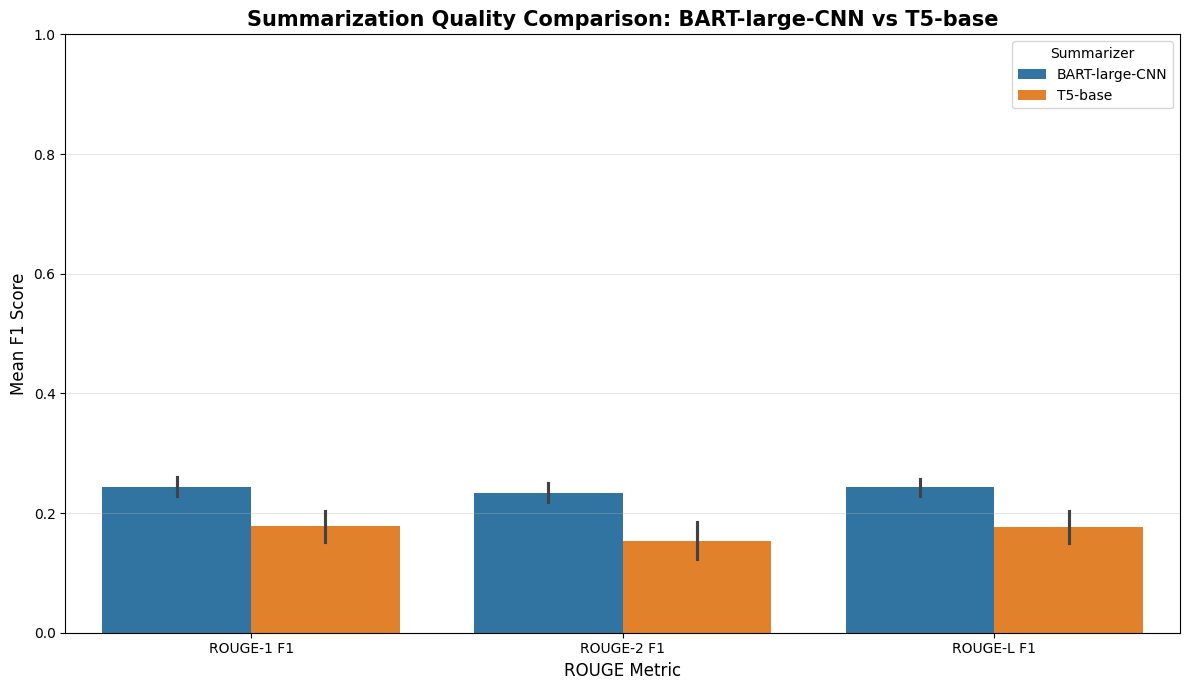

In [53]:
# Cell 28H: ROUGE comparison plot

rouge_plot_df = summarizer_comparison_df.melt(
    id_vars=["Query ID", "Summarizer"],
    value_vars=["ROUGE-1 F1", "ROUGE-2 F1", "ROUGE-L F1"],
    var_name="ROUGE Metric",
    value_name="F1 Score"
)

plt.figure(figsize=(12, 7))

sns.barplot(
    data=rouge_plot_df,
    x="ROUGE Metric",
    y="F1 Score",
    hue="Summarizer",
    errorbar="sd"
)

plt.title("Summarization Quality Comparison: BART-large-CNN vs T5-base", fontsize=15, fontweight="bold")
plt.xlabel("ROUGE Metric", fontsize=12)
plt.ylabel("Mean F1 Score", fontsize=12)
plt.ylim(0, 1)
plt.legend(title="Summarizer")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

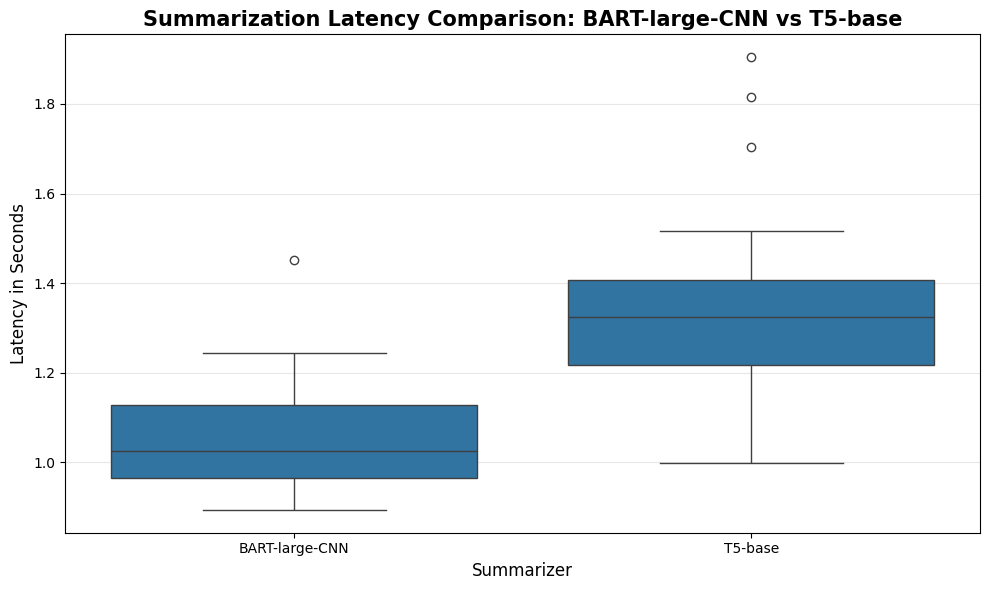

In [54]:
# Cell 28I: Summarization latency comparison

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=summarizer_comparison_df,
    x="Summarizer",
    y="Summarization Latency Seconds"
)

plt.title("Summarization Latency Comparison: BART-large-CNN vs T5-base", fontsize=15, fontweight="bold")
plt.xlabel("Summarizer", fontsize=12)
plt.ylabel("Latency in Seconds", fontsize=12)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [61]:
# Cell 28J: Enriched paired statistical tests for summarizers

from scipy.stats import (
    ttest_rel,
    wilcoxon,
    shapiro,
    normaltest,
    skew,
    kurtosis,
    pearsonr,
    spearmanr,
    bootstrap
)

import numpy as np
import pandas as pd

summarizer_stat_records = []

summary_metrics = [
    "ROUGE-1 F1",
    "ROUGE-2 F1",
    "ROUGE-L F1",
    "Compression Ratio",
    "Summarization Latency Seconds"
]

def paired_cohens_d(diff):
    sd = np.std(diff, ddof=1)
    return np.mean(diff) / sd if sd != 0 else np.nan

def hedges_g_from_d(d, n):
    if n <= 1 or np.isnan(d):
        return np.nan
    correction = 1 - (3 / (4*n - 9))
    return d * correction

def rank_biserial_from_wilcoxon(w_stat, n):
    if np.isnan(w_stat):
        return np.nan
    total_rank_sum = n * (n + 1) / 2
    return 1 - (2 * w_stat / total_rank_sum)

def cliffs_delta_paired(x, y):
    greater = np.sum(x > y)
    lesser = np.sum(x < y)
    n = len(x)
    return (greater - lesser) / n if n > 0 else np.nan

def mean_ci_bootstrap(diff, confidence_level=0.95, n_resamples=5000):
    try:
        res = bootstrap(
            (diff,),
            np.mean,
            confidence_level=confidence_level,
            n_resamples=n_resamples,
            method="percentile",
            random_state=42
        )
        return res.confidence_interval.low, res.confidence_interval.high
    except:
        return np.nan, np.nan

for metric in summary_metrics:

    bart_values = summarizer_comparison_df[
        summarizer_comparison_df["Summarizer"] == "BART-large-CNN"
    ].sort_values("Query ID")[metric].values.astype(float)

    t5_values = summarizer_comparison_df[
        summarizer_comparison_df["Summarizer"] == "T5-base"
    ].sort_values("Query ID")[metric].values.astype(float)

    diff = bart_values - t5_values
    n = len(diff)

    # Descriptive statistics
    bart_mean = np.mean(bart_values)
    bart_sd = np.std(bart_values, ddof=1)

    t5_mean = np.mean(t5_values)
    t5_sd = np.std(t5_values, ddof=1)

    diff_mean = np.mean(diff)
    diff_median = np.median(diff)
    diff_sd = np.std(diff, ddof=1)
    diff_min = np.min(diff)
    diff_max = np.max(diff)
    diff_skew = skew(diff, bias=False)
    diff_kurtosis = kurtosis(diff, bias=False)

    # Normality tests for paired differences
    try:
        shapiro_stat, shapiro_p = shapiro(diff)
    except:
        shapiro_stat, shapiro_p = np.nan, np.nan

    try:
        dagostino_stat, dagostino_p = normaltest(diff)
    except:
        dagostino_stat, dagostino_p = np.nan, np.nan

    # Parametric paired t-test
    try:
        t_stat, t_p = ttest_rel(bart_values, t5_values)
    except:
        t_stat, t_p = np.nan, np.nan

    # Non-parametric Wilcoxon signed-rank test
    try:
        w_stat, w_p = wilcoxon(bart_values, t5_values, zero_method="wilcox")
    except:
        w_stat, w_p = np.nan, np.nan

    # Effect sizes
    cohen_d = paired_cohens_d(diff)
    hedges_g = hedges_g_from_d(cohen_d, n)
    rank_biserial = rank_biserial_from_wilcoxon(w_stat, n)
    cliffs_delta = cliffs_delta_paired(bart_values, t5_values)

    # Bootstrap confidence interval for mean paired difference
    ci_low, ci_high = mean_ci_bootstrap(diff)

    # Correlation between summarizer outputs over query-level metric scores
    try:
        pearson_r, pearson_p = pearsonr(bart_values, t5_values)
    except:
        pearson_r, pearson_p = np.nan, np.nan

    try:
        spearman_r, spearman_p = spearmanr(bart_values, t5_values)
    except:
        spearman_r, spearman_p = np.nan, np.nan

    # Directional win counts
    bart_wins = int(np.sum(bart_values > t5_values))
    t5_wins = int(np.sum(t5_values > bart_values))
    ties = int(np.sum(bart_values == t5_values))

    summarizer_stat_records.append({
        "Metric": metric,
        "N Queries": n,

        "BART Mean": bart_mean,
        "BART SD": bart_sd,
        "T5 Mean": t5_mean,
        "T5 SD": t5_sd,

        "Mean Difference BART-T5": diff_mean,
        "Median Difference BART-T5": diff_median,
        "Difference SD": diff_sd,
        "Difference Min": diff_min,
        "Difference Max": diff_max,
        "Difference Skewness": diff_skew,
        "Difference Kurtosis": diff_kurtosis,

        "Bootstrap 95% CI Low": ci_low,
        "Bootstrap 95% CI High": ci_high,

        "Shapiro W": shapiro_stat,
        "Shapiro p": shapiro_p,
        "DAgostino K2": dagostino_stat,
        "DAgostino p": dagostino_p,

        "Paired t statistic": t_stat,
        "Paired t-test p": t_p,
        "Wilcoxon statistic": w_stat,
        "Wilcoxon p": w_p,

        "Paired Cohen d": cohen_d,
        "Hedges g": hedges_g,
        "Rank-biserial correlation": rank_biserial,
        "Paired Cliff delta": cliffs_delta,

        "Pearson r": pearson_r,
        "Pearson p": pearson_p,
        "Spearman rho": spearman_r,
        "Spearman p": spearman_p,

        "BART Wins": bart_wins,
        "T5 Wins": t5_wins,
        "Ties": ties
    })

summarizer_stat_tests_df = pd.DataFrame(summarizer_stat_records)

pd.set_option("display.max_columns", None)
summarizer_stat_tests_df

,Metric,N Queries,BART Mean,BART SD,T5 Mean,T5 SD,Mean Difference BART-T5,Median Difference BART-T5,Difference SD,Difference Min,Difference Max,Difference Skewness,Difference Kurtosis,Bootstrap 95% CI Low,Bootstrap 95% CI High,Shapiro W,Shapiro p,DAgostino K2,DAgostino p,Paired t statistic,Paired t-test p,Wilcoxon statistic,Wilcoxon p,Paired Cohen d,Hedges g,Rank-biserial correlation,Paired Cliff delta,Pearson r,Pearson p,Spearman rho,Spearman p,BART Wins,T5 Wins,Ties
0,ROUGE-1 F1,20,0.243807,0.015647,0.177700,0.026321,0.066107,0.072023,0.032612,0.011064,0.120175,-0.200091,-0.821785,0.051955,0.079723,0.955414,0.456760,1.007920,0.604134,9.065254,2.495486e-08,0.0,0.000002,2.027052,1.941402,1.000000,1.0,-0.152928,0.519781,-0.279578,0.232559,20,0,0
1,ROUGE-2 F1,20,0.234090,0.015340,0.153990,0.030395,0.080100,0.082314,0.035602,0.016227,0.141164,-0.051093,-0.753886,0.064655,0.095159,0.967915,0.710377,0.644196,0.724627,10.061726,4.765903e-09,0.0,0.000002,2.249870,2.154805,1.000000,1.0,-0.116184,0.625697,-0.129093,0.587525,20,0,0
2,ROUGE-L F1,20,0.242924,0.014161,0.176761,0.027139,0.066163,0.073194,0.032654,0.011064,0.120175,-0.180771,-0.776206,0.051854,0.079668,0.950931,0.381441,0.835719,0.658455,9.061455,2.511855e-08,0.0,0.000002,2.026203,1.940589,1.000000,1.0,-0.168074,0.478750,-0.198945,0.400418,20,0,0
3,Compression Ratio,20,0.143973,0.012680,0.113859,0.013520,0.030115,0.031319,0.018800,0.000000,0.062044,-0.052008,-0.859764,0.022080,0.038266,0.961811,0.580639,0.979618,0.612743,7.163611,8.297426e-07,0.0,0.000196,1.601832,1.534149,1.000000,0.9,-0.028809,0.904035,-0.073767,0.757263,18,0,2
4,Summarization Latency Seconds,20,1.058114,0.140673,1.346791,0.238940,-0.288677,-0.231047,0.229348,-0.849984,0.060179,-0.849156,0.519485,-0.387985,-0.195343,0.950789,0.379226,3.328366,0.189345,-5.629021,1.990249e-05,2.0,0.000006,-1.258687,-1.205503,0.980952,-0.9,0.361186,0.117670,0.189474,0.423665,1,19,0


In [56]:
# Cell 28K: Save summarizer comparison tables and figures

os.makedirs(output_dir, exist_ok=True)

summarizer_comparison_df.to_csv(
    f"{output_dir}/bart_t5_summarizer_query_level_comparison.csv",
    index=False
)

summarizer_summary_table.to_csv(
    f"{output_dir}/bart_t5_summarizer_summary_table.csv",
    index=False
)

summarizer_stat_tests_df.to_csv(
    f"{output_dir}/bart_t5_summarizer_statistical_tests.csv",
    index=False
)

print("Saved BART-T5 summarizer comparison outputs to:", output_dir)

Saved BART-T5 summarizer comparison outputs to: /content/ecotroph_rag_results


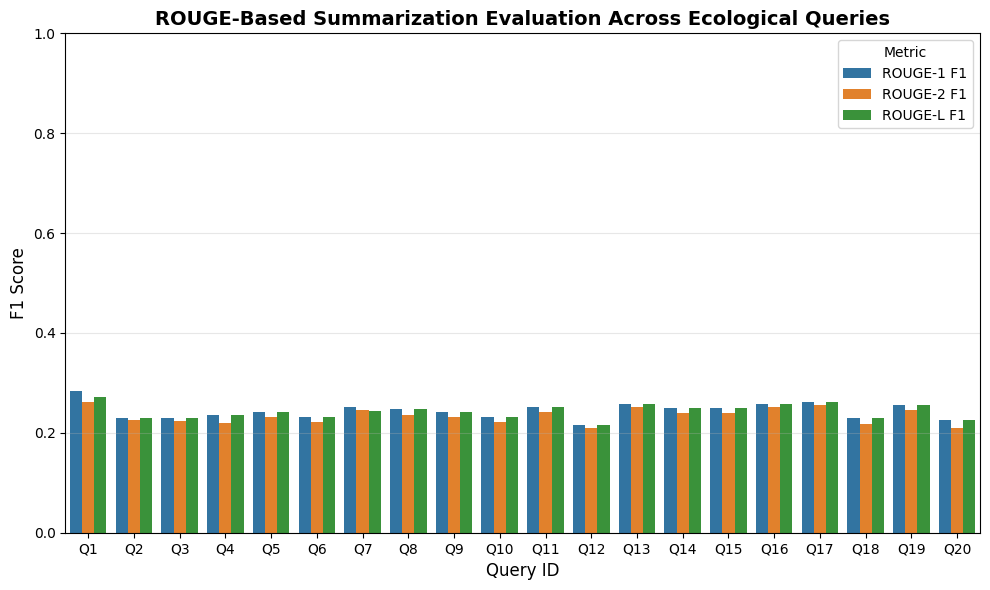

In [57]:
# Cell 29: Summary quality plots

plt.figure(figsize=(10, 6))

summary_plot_df = summary_table.melt(
    id_vars=["Query ID"],
    value_vars=["ROUGE-1 F1", "ROUGE-2 F1", "ROUGE-L F1"],
    var_name="ROUGE Metric",
    value_name="F1 Score"
)

sns.barplot(data=summary_plot_df, x="Query ID", y="F1 Score", hue="ROUGE Metric")

plt.title("ROUGE-Based Summarization Evaluation Across Ecological Queries", fontsize=14, fontweight="bold")
plt.xlabel("Query ID", fontsize=12)
plt.ylabel("F1 Score", fontsize=12)
plt.ylim(0, 1.0)
plt.legend(title="Metric")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

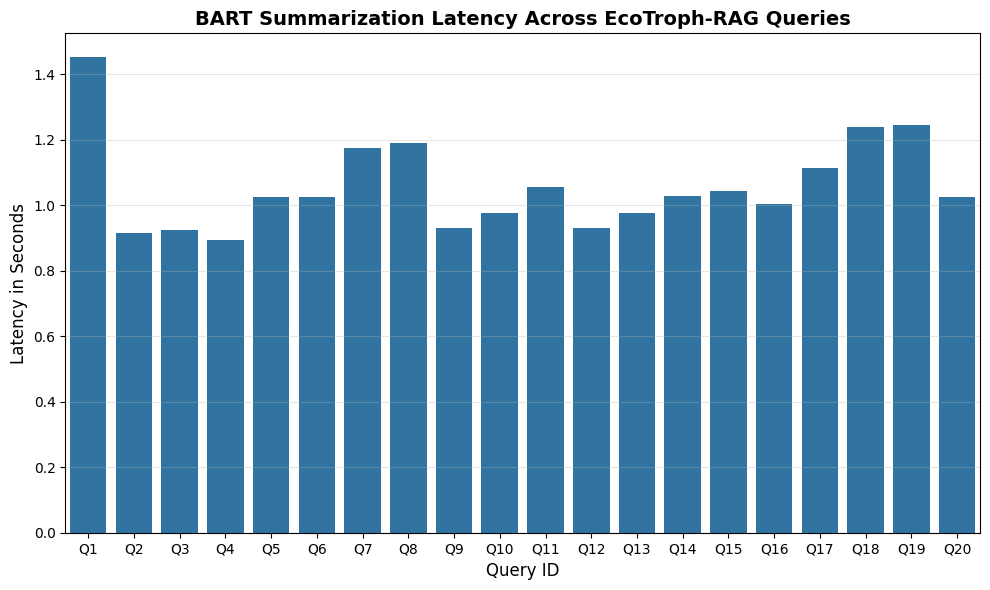

In [58]:
# Cell 30: Summarization latency plot

plt.figure(figsize=(10, 6))

sns.barplot(
    data=summary_eval_df,
    x="Query ID",
    y="Summarization Latency Seconds"
)

plt.title("BART Summarization Latency Across EcoTroph-RAG Queries", fontsize=14, fontweight="bold")
plt.xlabel("Query ID", fontsize=12)
plt.ylabel("Latency in Seconds", fontsize=12)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [59]:
# Cell 31: Display final RAG outputs

for _, row in summary_eval_df.iterrows():
    print("=" * 100)
    print("Query ID:", row["Query ID"])
    print("Query:", row["Query"])
    print("\nGenerated EcoTroph-RAG Summary:")
    print(row["Generated Summary"])
    print("=" * 100)

Query ID: Q1
Query: Which fish species consume crustaceans in lotic habitats?

Generated EcoTroph-RAG Summary:
Evidence from freshwater fish diet records: Fish species Notropis biguttatus consumed prey taxon crustacea remains from prey kingdom Metazoa and prey class not reported. The prey origin was not reported and prey stage was not report. The diet value was 0.3 percent, measured as volume, with diet percent 0.4 percent.
Query ID: Q2
Query: Which fish consume aquatic insect larvae?

Generated EcoTroph-RAG Summary:
Fish species Salvelinus fontinalis consumed prey taxon triehoptera larvae from prey kingdom Metazoa and prey class Insecta. The prey origin was aquatic and prey stage was larvae. The diet value was 0.0 individuals, measured as abundance.
Query ID: Q3
Query: Which fish species consume Odonata prey?

Generated EcoTroph-RAG Summary:
Fish species Salmo trutta consumed prey taxon odonata from prey kingdom Metazoa and prey class Insecta. The prey origin was aquatic and prey stag

In [60]:
# Cell 32: Export all result tables

output_dir = "/content/ecotroph_rag_results"
os.makedirs(output_dir, exist_ok=True)

stats_df.to_csv(f"{output_dir}/dataset_statistics.csv", index=False)
retrieval_eval_df.to_csv(f"{output_dir}/query_level_retrieval_evaluation.csv", index=False)
retrieval_summary.to_csv(f"{output_dir}/retrieval_summary.csv", index=False)
statistical_tests_df.to_csv(f"{output_dir}/statistical_tests.csv", index=False)
summary_eval_df.to_csv(f"{output_dir}/summarization_evaluation.csv", index=False)

print("Saved result tables to:", output_dir)

Saved result tables to: /content/ecotroph_rag_results


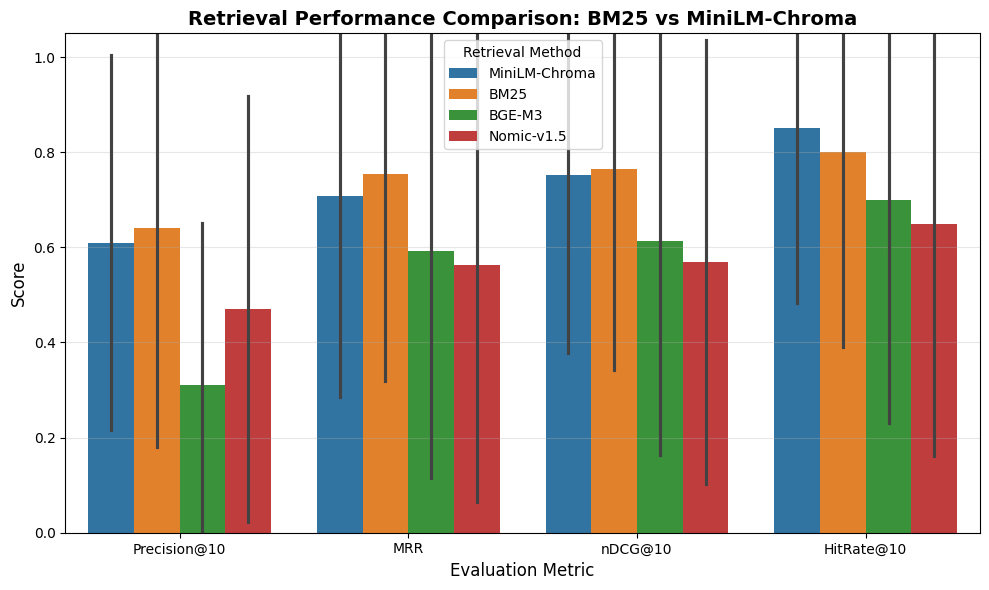

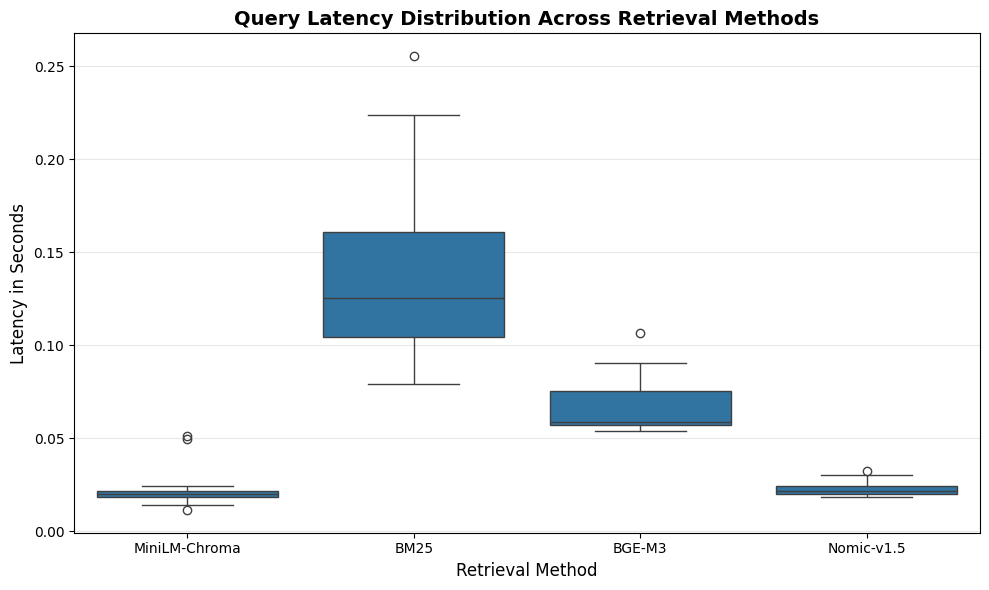

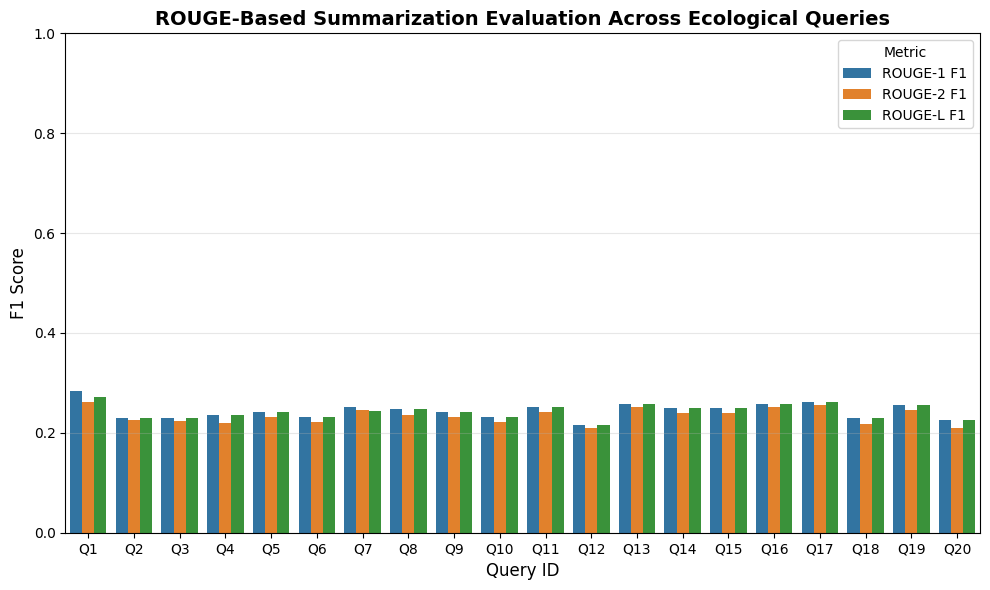

In [45]:
# Cell 33: Save publication figures

# Figure 1: Retrieval performance

plt.figure(figsize=(10, 6))
sns.barplot(data=plot_df, x="Metric", y="Score", hue="Method", errorbar="sd")
plt.title("Retrieval Performance Comparison: BM25 vs MiniLM-Chroma", fontsize=14, fontweight="bold")
plt.xlabel("Evaluation Metric", fontsize=12)
plt.ylabel("Score", fontsize=12)
plt.ylim(0, 1.05)
plt.legend(title="Retrieval Method")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(f"{output_dir}/figure_retrieval_performance.png", dpi=300)
plt.show()

# Figure 2: Latency

plt.figure(figsize=(10, 6))
sns.boxplot(data=retrieval_eval_df, x="Method", y="Latency Seconds")
plt.title("Query Latency Distribution Across Retrieval Methods", fontsize=14, fontweight="bold")
plt.xlabel("Retrieval Method", fontsize=12)
plt.ylabel("Latency in Seconds", fontsize=12)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(f"{output_dir}/figure_query_latency.png", dpi=300)
plt.show()

# Figure 3: ROUGE

plt.figure(figsize=(10, 6))
sns.barplot(data=summary_plot_df, x="Query ID", y="F1 Score", hue="ROUGE Metric")
plt.title("ROUGE-Based Summarization Evaluation Across Ecological Queries", fontsize=14, fontweight="bold")
plt.xlabel("Query ID", fontsize=12)
plt.ylabel("F1 Score", fontsize=12)
plt.ylim(0, 1.0)
plt.legend(title="Metric")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(f"{output_dir}/figure_rouge_scores.png", dpi=300)
plt.show()

In [ ]:
# Cell 34: Download result files


import shutil
from google.colab import files

zip_path = "/content/ecotroph_rag_results.zip"
shutil.make_archive("/content/ecotroph_rag_results", "zip", output_dir)

files.download(zip_path)

In [ ]:
# Explainability



SHAP was applied to random-forest surrogate models trained on query-level evaluation outcomes. Therefore, SHAP values do not explain the internal transformer parameters directly; rather, they explain which experimental factors, retrieval methods, query difficulty levels, latency values, and summary characteristics most strongly contributed to observed retrieval and summarization performance.


In [65]:
# SHAP

!pip install -q shap

In [66]:
# Prepare retrieval SHAP dataset

import shap
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

retrieval_shap_df = retrieval_eval_df.merge(
    query_validation_df[["Query ID", "Matching Dataset Rows", "Query Difficulty"]],
    on="Query ID",
    how="left"
)

retrieval_shap_df["Log Matching Rows"] = np.log1p(retrieval_shap_df["Matching Dataset Rows"])

retrieval_shap_df.head()

,Query ID,Query,Method,Latency Seconds,Precision@10,HitRate@10,MRR,nDCG@10,Relevant Retrieved,Matching Dataset Rows,Query Difficulty,Log Matching Rows
0,Q1,Which fish species consume crustaceans in loti...,MiniLM-Chroma,0.018620,0.9,1,1.0,0.997188,9,245,Moderate-frequency,5.505332
1,Q1,Which fish species consume crustaceans in loti...,BM25,0.130241,0.0,0,0.0,0.000000,0,245,Moderate-frequency,5.505332
2,Q1,Which fish species consume crustaceans in loti...,BGE-M3,0.106411,0.0,0,0.0,0.000000,0,245,Moderate-frequency,5.505332
3,Q1,Which fish species consume crustaceans in loti...,Nomic-v1.5,0.024180,0.0,0,0.0,0.000000,0,245,Moderate-frequency,5.505332
4,Q2,Which fish consume aquatic insect larvae?,MiniLM-Chroma,0.011449,1.0,1,1.0,1.000000,10,5397,High-frequency,8.593784


In [67]:
# SHAP for retrieval accuracy, nDCG@10

target_metric = "nDCG@10"

features = [
    "Method",
    "Query Difficulty",
    "Log Matching Rows",
    "Latency Seconds",
    "Precision@10",
    "HitRate@10",
    "MRR"
]

X = retrieval_shap_df[features]
y = retrieval_shap_df[target_metric]

categorical_features = ["Method", "Query Difficulty"]
numeric_features = [
    "Log Matching Rows",
    "Latency Seconds",
    "Precision@10",
    "HitRate@10",
    "MRR"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numeric_features)
    ]
)

rf_model = RandomForestRegressor(
    n_estimators=500,
    random_state=42,
    max_depth=4
)

retrieval_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", rf_model)
])

retrieval_pipeline.fit(X, y)

cv_scores = cross_val_score(
    retrieval_pipeline,
    X,
    y,
    cv=5,
    scoring="r2"
)

print("Target:", target_metric)
print("Cross-validated R2 scores:", cv_scores)
print("Mean CV R2:", cv_scores.mean())

Target: nDCG@10
Cross-validated R2 scores: [0.99348982 0.99378317 0.97895295 0.99546362 0.96785768]
Mean CV R2: 0.9859094476068411


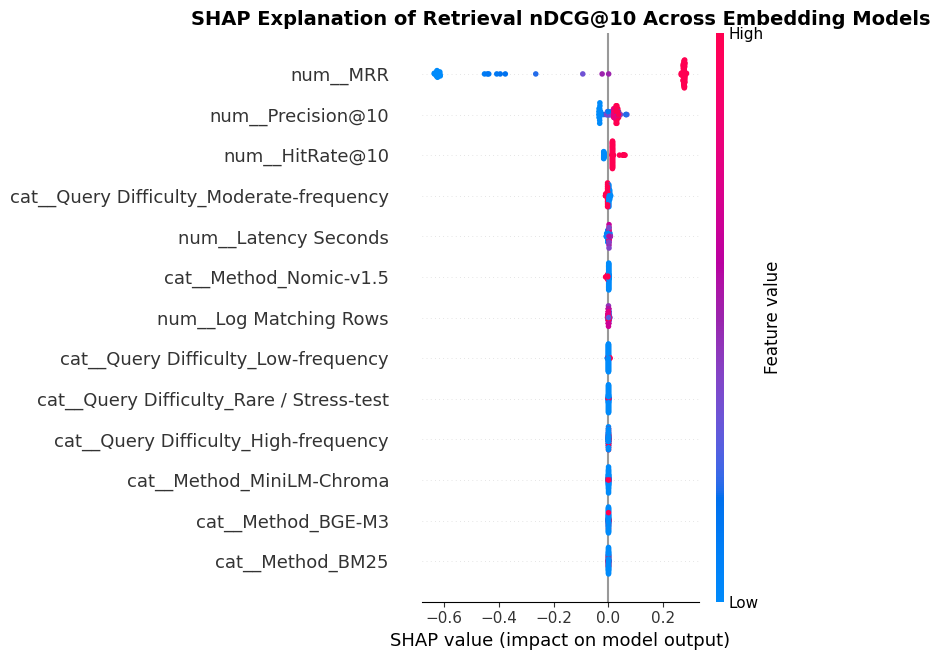

In [68]:
# Retrieval SHAP summary plot

X_transformed = retrieval_pipeline.named_steps["preprocessor"].transform(X)

feature_names = retrieval_pipeline.named_steps["preprocessor"].get_feature_names_out()

rf_fitted = retrieval_pipeline.named_steps["model"]

explainer = shap.TreeExplainer(rf_fitted)
shap_values = explainer.shap_values(X_transformed)

plt.figure(figsize=(12, 7))
shap.summary_plot(
    shap_values,
    X_transformed,
    feature_names=feature_names,
    show=False
)

plt.title("SHAP Explanation of Retrieval nDCG@10 Across Embedding Models", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

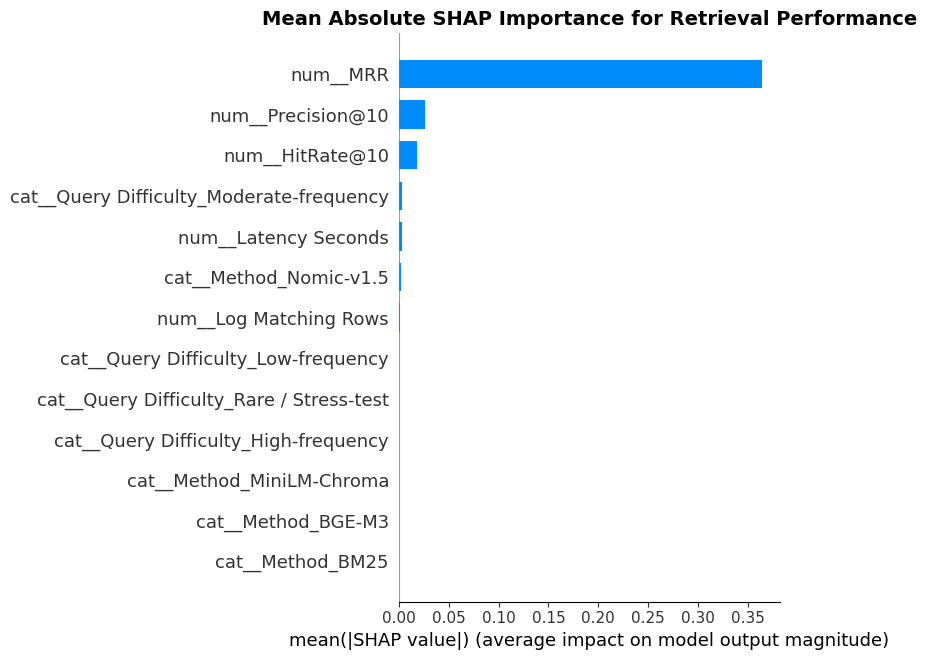

In [69]:
#Retrieval SHAP bar plot

plt.figure(figsize=(10, 6))

shap.summary_plot(
    shap_values,
    X_transformed,
    feature_names=feature_names,
    plot_type="bar",
    show=False
)

plt.title("Mean Absolute SHAP Importance for Retrieval Performance", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [ ]:
# SHAP for Summarizer Models

In [70]:
# Prepare summarizer SHAP dataset

summarizer_shap_df = summarizer_comparison_df.merge(
    query_validation_df[["Query ID", "Matching Dataset Rows", "Query Difficulty"]],
    on="Query ID",
    how="left"
)

summarizer_shap_df["Log Matching Rows"] = np.log1p(summarizer_shap_df["Matching Dataset Rows"])

summarizer_shap_df.head()

,Query ID,Query,Summarizer,Generated Summary,Evidence Length Words,Summary Length Words,Compression Ratio,ROUGE-1 F1,ROUGE-2 F1,ROUGE-L F1,Summarization Latency Seconds,Matching Dataset Rows,Query Difficulty,Log Matching Rows
0,Q1,Which fish species consume crustaceans in loti...,BART-large-CNN,Evidence from freshwater fish diet records: Fi...,274,50,0.182482,0.283237,0.261628,0.271676,1.451878,245,Moderate-frequency,5.505332
1,Q2,Which fish consume aquatic insect larvae?,BART-large-CNN,Fish species Salvelinus fontinalis consumed pr...,265,36,0.135849,0.229814,0.225000,0.229814,0.913868,5397,High-frequency,8.593784
2,Q3,Which fish species consume Odonata prey?,BART-large-CNN,Fish species Salmo trutta consumed prey taxon ...,268,36,0.134328,0.229102,0.224299,0.229102,0.923579,450,Moderate-frequency,6.111467
3,Q4,What prey taxa are consumed in lentic habitats?,BART-large-CNN,Fish species Protopterus annectens consumed pr...,271,38,0.140221,0.236364,0.219512,0.236364,0.893243,24171,High-frequency,10.092950
4,Q5,Which fish consume plant-based prey?,BART-large-CNN,Fish species Steindachnerina gracilis consumed...,286,42,0.146853,0.241379,0.231214,0.241379,1.025444,4776,High-frequency,8.471568


In [71]:
# SHAP for summarization quality, ROUGE-L

target_metric = "ROUGE-L F1"

features = [
    "Summarizer",
    "Query Difficulty",
    "Log Matching Rows",
    "Evidence Length Words",
    "Summary Length Words",
    "Compression Ratio",
    "Summarization Latency Seconds",
    "ROUGE-1 F1",
    "ROUGE-2 F1"
]

X = summarizer_shap_df[features]
y = summarizer_shap_df[target_metric]

categorical_features = ["Summarizer", "Query Difficulty"]
numeric_features = [
    "Log Matching Rows",
    "Evidence Length Words",
    "Summary Length Words",
    "Compression Ratio",
    "Summarization Latency Seconds",
    "ROUGE-1 F1",
    "ROUGE-2 F1"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numeric_features)
    ]
)

rf_model = RandomForestRegressor(
    n_estimators=500,
    random_state=42,
    max_depth=4
)

summarizer_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", rf_model)
])

summarizer_pipeline.fit(X, y)

cv_scores = cross_val_score(
    summarizer_pipeline,
    X,
    y,
    cv=5,
    scoring="r2"
)

print("Target:", target_metric)
print("Cross-validated R2 scores:", cv_scores)
print("Mean CV R2:", cv_scores.mean())

Target: ROUGE-L F1
Cross-validated R2 scores: [0.81990683 0.98720036 0.97708604 0.90315675 0.97384065]
Mean CV R2: 0.9322381246065913


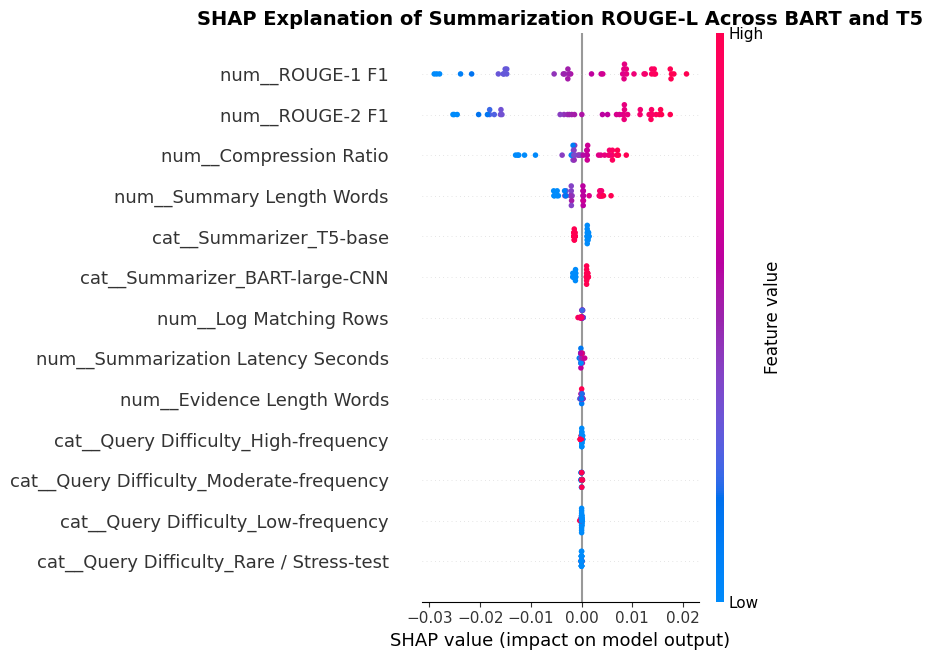

In [72]:
#Summarizer SHAP summary plot

X_transformed = summarizer_pipeline.named_steps["preprocessor"].transform(X)

feature_names = summarizer_pipeline.named_steps["preprocessor"].get_feature_names_out()

rf_fitted = summarizer_pipeline.named_steps["model"]

explainer = shap.TreeExplainer(rf_fitted)
shap_values = explainer.shap_values(X_transformed)

plt.figure(figsize=(12, 7))

shap.summary_plot(
    shap_values,
    X_transformed,
    feature_names=feature_names,
    show=False
)

plt.title("SHAP Explanation of Summarization ROUGE-L Across BART and T5", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

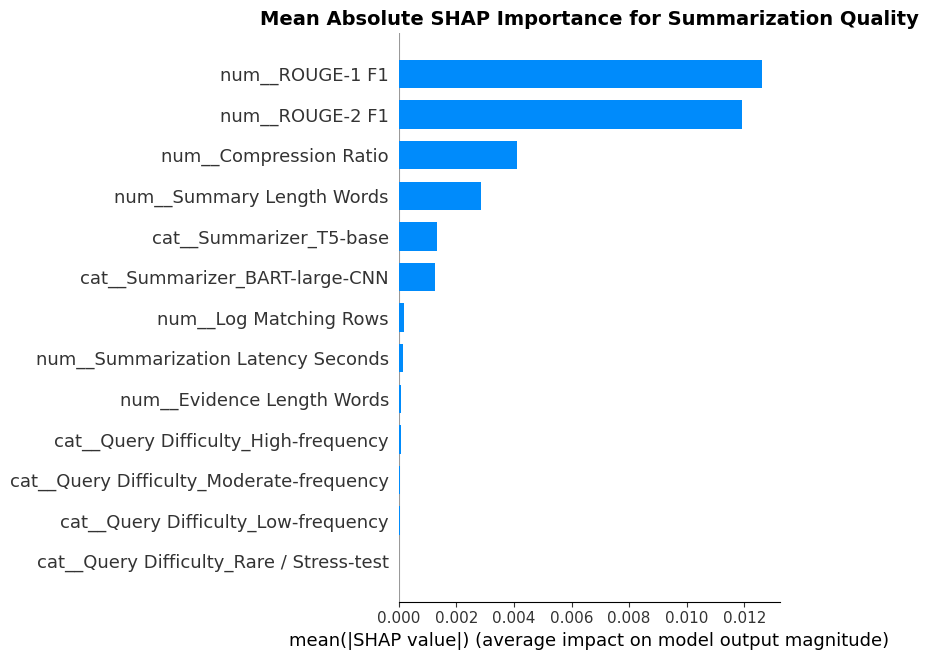

In [73]:
# Summarizer SHAP bar plot

plt.figure(figsize=(10, 6))

shap.summary_plot(
    shap_values,
    X_transformed,
    feature_names=feature_names,
    plot_type="bar",
    show=False
)

plt.title("Mean Absolute SHAP Importance for Summarization Quality", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()